In [5]:
import pandas as pd
from db_operations import get_db_conn

def count_stats(project_type="all", is_active=False, limit=10):
    conn = get_db_conn()
    cur = conn.cursor()

    # Base query
    query = """
    SELECT
        LOWER(organization) AS organization,
        COUNT(DISTINCT repository_url) AS total_projects,
        (
            COALESCE(SUM(same_license), 0) +
            COALESCE(SUM(dif_license_comply), 0) +
            COALESCE(SUM(license_conflicts), 0) +
            COALESCE(SUM(high_risks), 0) +
            COALESCE(SUM(undetermined), 0) +
            COALESCE(SUM(no_match), 0)
        ) AS total_methods,
        SUM(same_license) AS same_license,
        SUM(dif_license_comply) AS diff_license_comply,
        SUM(license_conflicts) AS license_conflicts,
        SUM(high_risks) AS high_risks,
        SUM(undetermined) AS undetermined,
        SUM(no_match) AS no_match
    FROM searchrepos
    WHERE is_active = %s
    """
    params = [is_active]

    # Handle project_type filter
    if project_type == "all":
        query += " AND project_type IN (1,2,3)"
    else:
        query += " AND project_type = %s"
        params.append(project_type)

    # Add GROUP BY, ORDER BY and dynamic LIMIT
    query += f" GROUP BY LOWER(organization) ORDER BY total_methods DESC LIMIT {limit};"

    # Execute query
    cur.execute(query, tuple(params))
    rows = cur.fetchall()
    columns = [desc[0] for desc in cur.description]

    df = pd.DataFrame(rows, columns=columns)

    # Derived column
    df["conflict_and_risks"] = df["license_conflicts"] + df["high_risks"]

    # Add percentage columns
    categories = [
        "same_license", "diff_license_comply", "license_conflicts",
        "high_risks", "undetermined", "no_match", "conflict_and_risks"
    ]

    for cat in categories:
        df[cat] = df.apply(
            lambda row: f"{row[cat]} ({(row[cat] / row['total_methods'] * 100):.1f}%)"
            if row['total_methods'] > 0 else f"{row[cat]} (0.0%)",
            axis=1
        )

    df.to_csv("org_license_stats.csv", index=False)

    cur.close()
    conn.close()
    return df


In [7]:
# Top 10 rows (default)
#count_stats(project_type="all")

# Top 30 rows
#count_stats(project_type="all", limit=30)

# Top 5 rows for project_type 2
count_stats(project_type=1, limit=5)

,organization,total_projects,total_methods,same_license,diff_license_comply,license_conflicts,high_risks,undetermined,no_match,conflict_and_risks
0,apple,298,11431,1372 (12.0%),282 (2.5%),80 (0.7%),5640 (49.3%),4 (0.0%),4053 (35.5%),5720 (50.0%)
1,ibm,229,3203,922 (28.8%),870 (27.2%),136 (4.2%),829 (25.9%),1 (0.0%),445 (13.9%),965 (30.1%)
2,microsoft,93,2897,123 (4.2%),425 (14.7%),421 (14.5%),928 (32.0%),0 (0.0%),1000 (34.5%),1349 (46.6%)
3,intel,94,2558,78 (3.0%),24 (0.9%),626 (24.5%),1244 (48.6%),0 (0.0%),586 (22.9%),1870 (73.1%)
4,samsung,1,1162,408 (35.1%),164 (14.1%),21 (1.8%),522 (44.9%),0 (0.0%),47 (4.0%),543 (46.7%)


In [13]:
from db_operations import get_db_conn

def fetch_undetermined_records():
    conn = get_db_conn()
    cur = conn.cursor()

    query = """
        SELECT *
        FROM searchrepos
        WHERE undetermined > 20;
    """
    
    cur.execute(query)
    rows = cur.fetchall()

    for row in rows:
        print(row)

    cur.close()
    conn.close()

# Run it
fetch_undetermined_records()

In [28]:
import csv
from db_operations import get_db_conn

def fetch_undetermined_records_to_csv(output_file="undetermined_records.csv"):
    conn = get_db_conn()
    cur = conn.cursor()

    query = """
        SELECT *
        FROM repository_data
        WHERE relational_id='20250820114130581503_764503';
    """
    
    cur.execute(query)
    rows = cur.fetchall()
    headers = [desc[0] for desc in cur.description]  # Get column names

    # Write to CSV
    with open(output_file, mode="w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(headers)  # Write column headers
        writer.writerows(rows)    # Write all rows

    print(f"Exported {len(rows)} rows to {output_file}")

    cur.close()
    conn.close()

# Run it
fetch_undetermined_records_to_csv()

Exported 741 rows to undetermined_records.csv


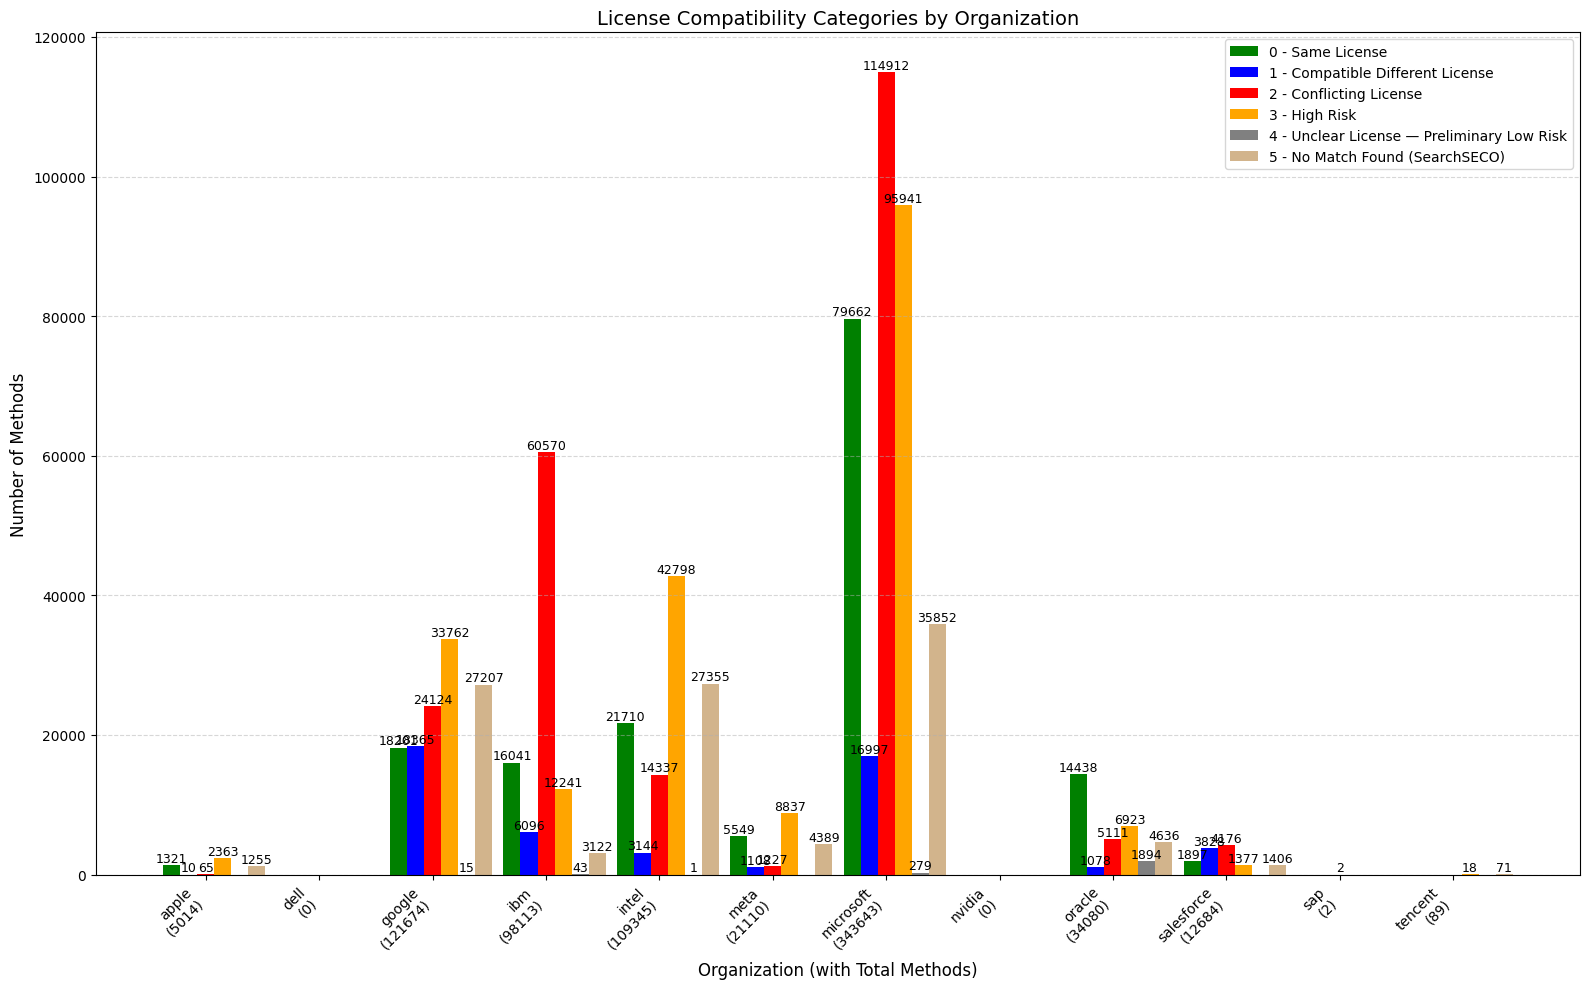

In [6]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn

def fetch_license_category_counts():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch category counts and total method count per organization
    cur.execute("""
        SELECT
            LOWER(organization),
            SUM(same_license) AS cat0,
            SUM(dif_license_comply) AS cat1,
            SUM(license_conflicts) AS cat2,
            SUM(high_risks) AS cat3,
            SUM(undetermined) AS cat4,
            SUM(no_match) AS cat5,
            (
                COALESCE(SUM(same_license), 0) +
                COALESCE(SUM(dif_license_comply), 0) +
                COALESCE(SUM(license_conflicts), 0) +
                COALESCE(SUM(high_risks), 0) +
                COALESCE(SUM(undetermined), 0) +
                COALESCE(SUM(no_match), 0)
            ) AS total_methods
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY LOWER(organization);
    """)

    company_category_data = {}
    for row in cur.fetchall():
        org = row[0]
        company_category_data[org] = {
            0: row[1] or 0,
            1: row[2] or 0,
            2: row[3] or 0,
            3: row[4] or 0,
            4: row[5] or 0,
            5: row[6] or 0,
            'total_methods': row[7]
        }

    cur.close()
    conn.close()
    return company_category_data

def plot_license_categories(company_category_data):
    companies = sorted(company_category_data.keys())
    x = range(len(companies))
    width = 0.15

    # Extract data per category
    category_0 = [company_category_data[c][0] for c in companies]
    category_1 = [company_category_data[c][1] for c in companies]
    category_2 = [company_category_data[c][2] for c in companies]
    category_3 = [company_category_data[c][3] for c in companies]
    category_4 = [company_category_data[c][4] for c in companies]
    category_5 = [company_category_data[c][5] for c in companies]
    total_methods = [company_category_data[c]['total_methods'] for c in companies]

    # Append total_methods to company labels
    labels = [f"{c}\n({total_methods[i]})" for i, c in enumerate(companies)]

    plt.figure(figsize=(16, 10))
    bars0 = plt.bar([i - 2*width for i in x], category_0, width=width, label='0 - Same License', color='green')
    bars1 = plt.bar([i - width for i in x], category_1, width=width, label='1 - Compatible Different License', color='blue')
    bars2 = plt.bar(x, category_2, width=width, label='2 - Conflicting License', color='red')
    bars3 = plt.bar([i + width for i in x], category_3, width=width, label='3 - High Risk', color='orange')
    bars4 = plt.bar([i + 2*width for i in x], category_4, width=width, label='4 - Unclear License — Preliminary Low Risk', color='gray')
    bars5 = plt.bar([i + 3*width for i in x], category_5, width=width, label='5 - No Match Found (SearchSECO)', color='tan')

    # Helper to annotate bars
    def annotate_bars(bars):
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2, height + 30, f'{int(height)}',
                         ha='center', va='bottom', fontsize=9)

    # Annotate each bar group
    for bars in [bars0, bars1, bars2, bars3, bars4, bars5]:
        annotate_bars(bars)

    plt.xlabel('Organization (with Total Methods)', fontsize=12)
    plt.ylabel('Number of Methods', fontsize=12)
    plt.title('License Compatibility Categories by Organization', fontsize=14)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

# Run
company_category_data = fetch_license_category_counts()
plot_license_categories(company_category_data)

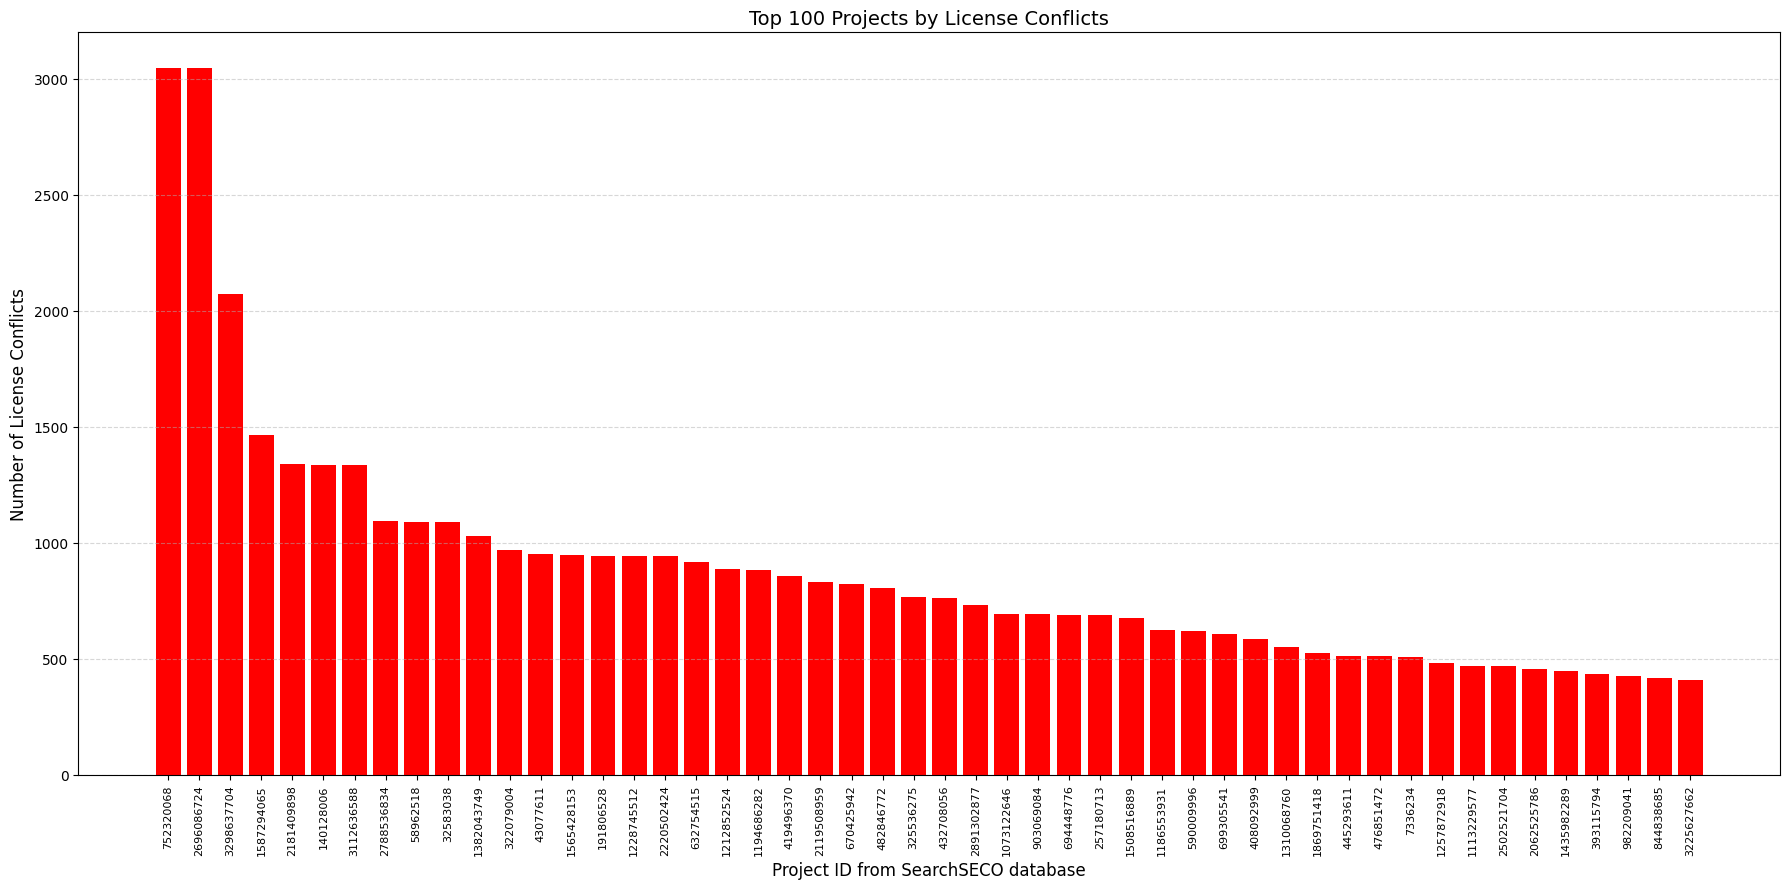

In [16]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn

def fetch_project_license_conflicts():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            project_id,
            SUM(license_conflicts) AS conflicts
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY project_id
        ORDER BY conflicts DESC
        LIMIT 50;
    """)

    project_conflicts = {}
    for row in cur.fetchall():
        project_conflicts[row[0]] = row[1] or 0

    cur.close()
    conn.close()
    return project_conflicts


def plot_project_license_conflicts(project_conflicts):
    projects = list(project_conflicts.keys())
    conflicts = list(project_conflicts.values())

    plt.figure(figsize=(18, 9))
    bars = plt.bar(projects, conflicts, color='red')

    # Annotate bar values (optional, might get cluttered with 100 projects)
    """
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{int(height)}',
                     ha='center', va='bottom', fontsize=7, rotation=90)
    """
    plt.xlabel('Project ID from SearchSECO database', fontsize=12)
    plt.ylabel('Number of License Conflicts', fontsize=12)
    plt.title('Top 100 Projects by License Conflicts', fontsize=14)
    plt.xticks(rotation=90, ha='center', fontsize=8)  # tighter for readability
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


# Run
project_conflicts = fetch_project_license_conflicts()
plot_project_license_conflicts(project_conflicts)

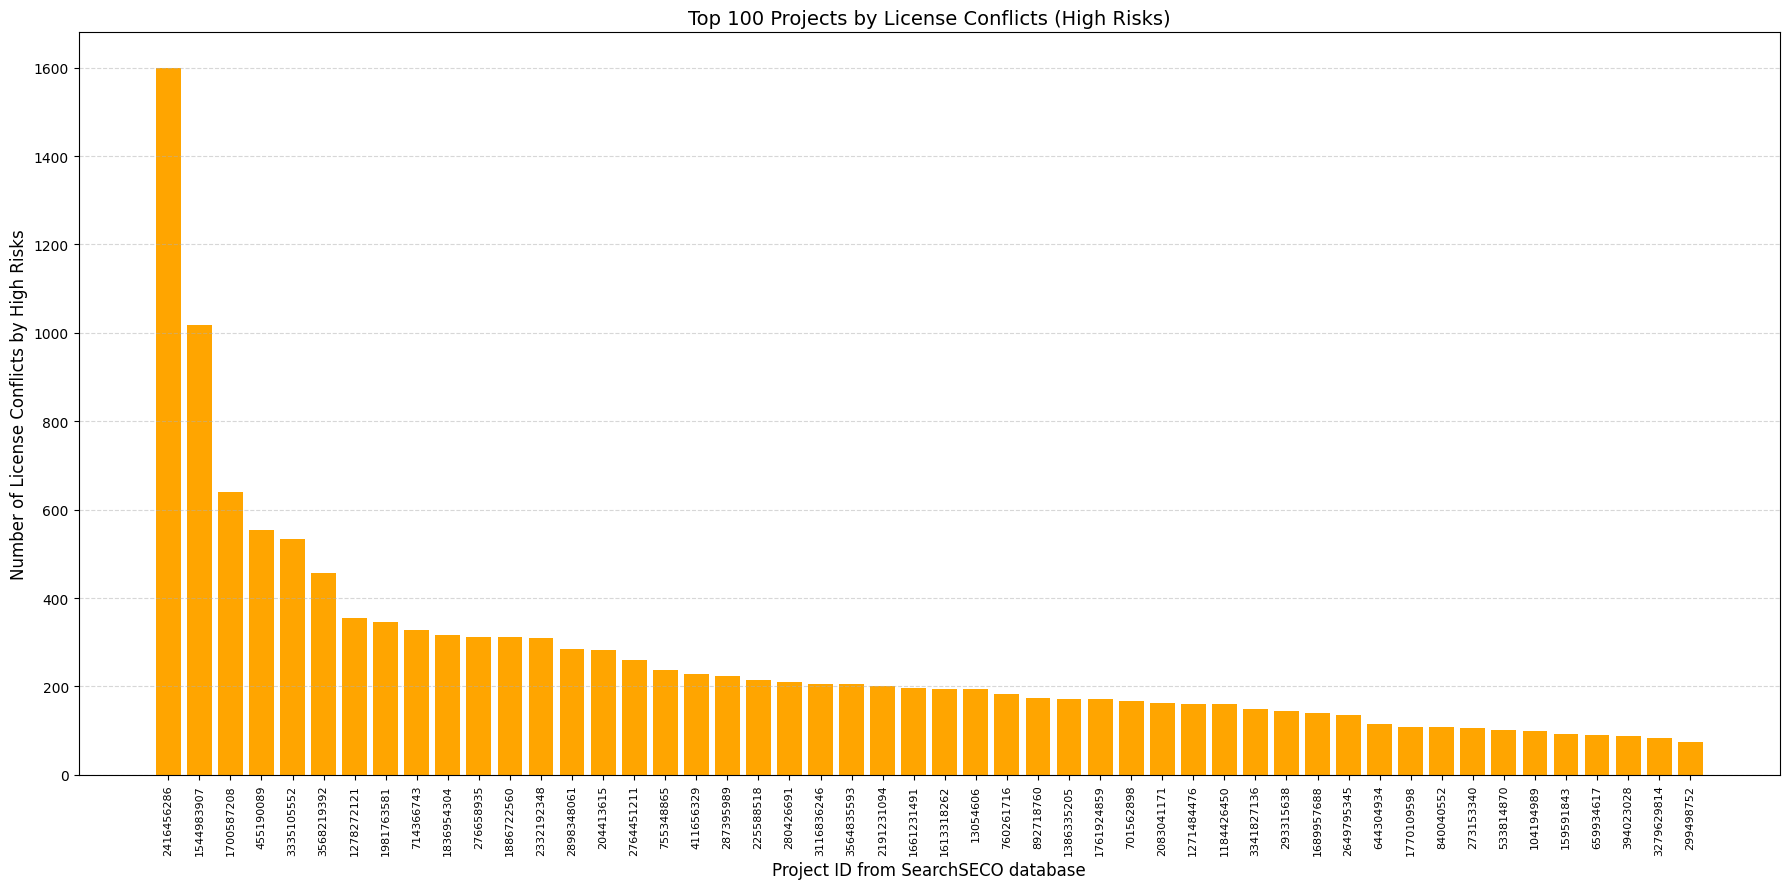

In [17]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn

def fetch_project_license_conflicts():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            project_id,
            SUM(high_risks) AS high_risks
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 2
        GROUP BY project_id
        ORDER BY high_risks DESC
        LIMIT 50;
    """)

    project_conflicts = {}
    for row in cur.fetchall():
        project_conflicts[row[0]] = row[1] or 0

    cur.close()
    conn.close()
    return project_conflicts


def plot_project_license_conflicts(project_conflicts):
    projects = list(project_conflicts.keys())
    conflicts = list(project_conflicts.values())

    plt.figure(figsize=(18, 9))
    bars = plt.bar(projects, conflicts, color='orange')

    # Annotate bar values (optional, might get cluttered with 100 projects)
    """
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height + 2, f'{int(height)}',
                     ha='center', va='bottom', fontsize=7, rotation=90)
    """
    plt.xlabel('Project ID from SearchSECO database', fontsize=12)
    plt.ylabel('Number of License Conflicts by High Risks', fontsize=12)
    plt.title('Top 100 Projects by License Conflicts (High Risks)', fontsize=14)
    plt.xticks(rotation=90, ha='center', fontsize=8)  # tighter for readability
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


# Run
project_conflicts = fetch_project_license_conflicts()
plot_project_license_conflicts(project_conflicts)

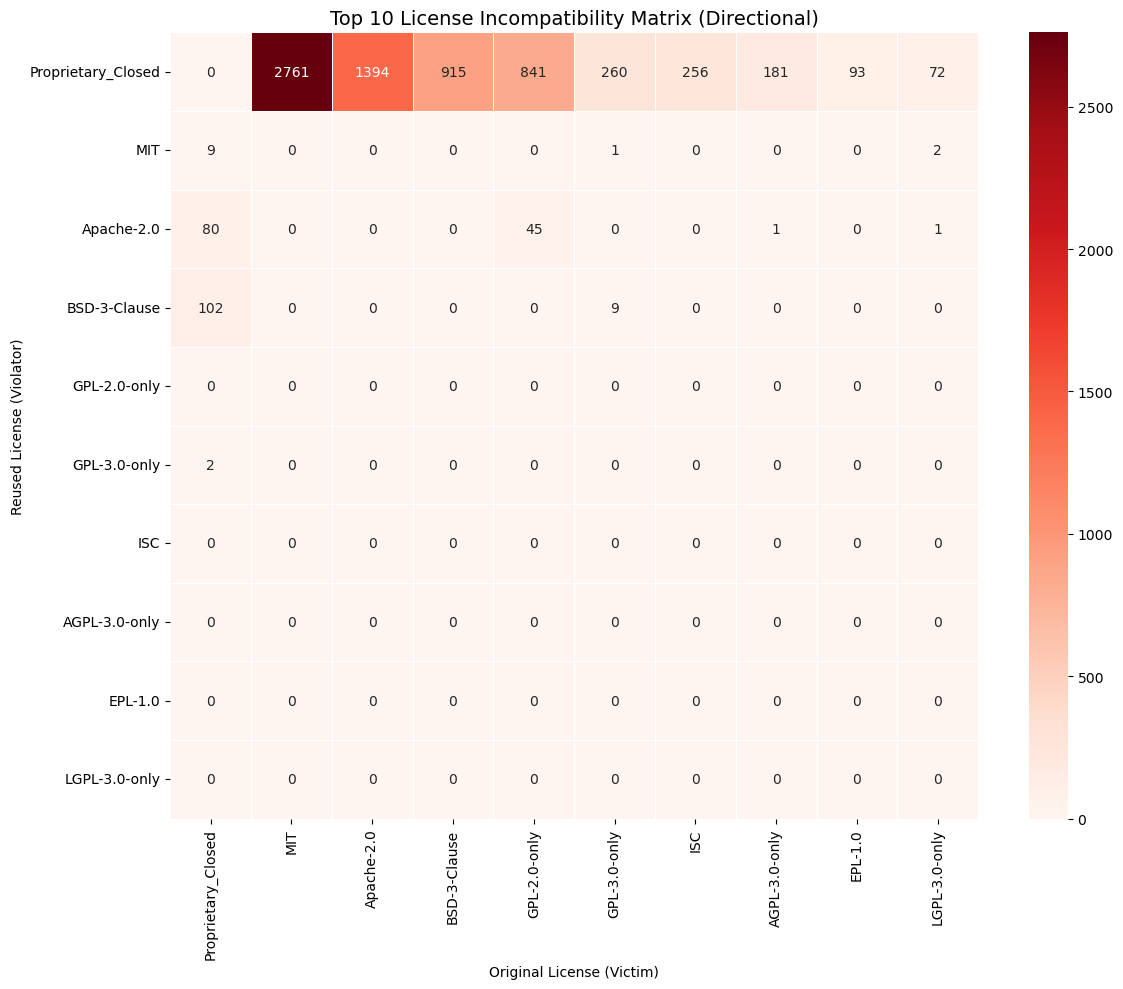

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from db_operations import get_db_conn

def fetch_license_conflicts():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT violation
        FROM repository_data
        WHERE violation IS NOT NULL AND violation <> '';
    """)

    violations = [row[0] for row in cur.fetchall()]

    cur.close()
    conn.close()
    return violations


def build_license_matrix(violations, top_n=10):
    pair_counts = Counter()

    for v in violations:
        if "incompatible with" in v:
            left, right = v.split("incompatible with")
            left = left.strip()
            right = right.strip()
            pair_counts[(left, right)] += 1  # directional

    # Count total participation per license
    license_counts = Counter()
    for (l1, l2), count in pair_counts.items():
        license_counts[l1] += count   # as violator
        license_counts[l2] += count   # as original victim

    top_licenses = [lic for lic, _ in license_counts.most_common(top_n)]

    # Build directional NxN matrix
    matrix = pd.DataFrame(0, index=top_licenses, columns=top_licenses)

    for (l1, l2), count in pair_counts.items():
        if l1 in top_licenses and l2 in top_licenses:
            matrix.loc[l1, l2] = count  # keep direction only

    return matrix


def plot_license_heatmap(matrix):
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Reds",
        cbar=True,
        linewidths=0.5
    )
    plt.title("Top 10 License Incompatibility Matrix (Directional)", fontsize=14)
    plt.xlabel("Original License (Victim)")
    plt.ylabel("Reused License (Violator)")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    violations = fetch_license_conflicts()
    matrix = build_license_matrix(violations, top_n=10)
    plot_license_heatmap(matrix)

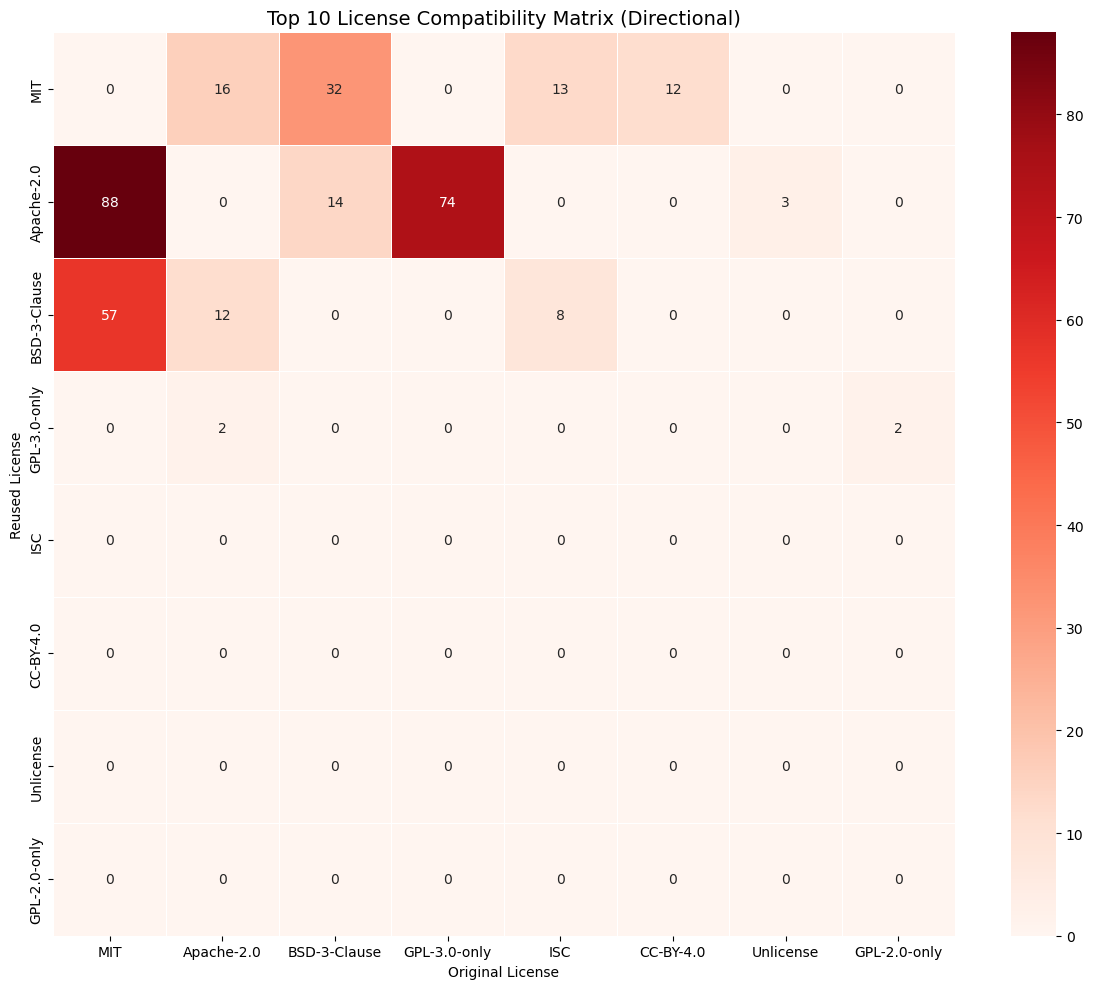

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from db_operations import get_db_conn

def fetch_license_conflicts():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT violation
        FROM repository_data
        WHERE violation IS NOT NULL AND violation <> '';
    """)

    violations = [row[0] for row in cur.fetchall()]

    cur.close()
    conn.close()
    return violations


def build_license_matrix(violations, top_n=10):
    pair_counts = Counter()

    for v in violations:
        if " compatible with" in v:
            left, right = v.split(" compatible with")
            left = left.strip()
            right = right.strip()
            pair_counts[(left, right)] += 1  # directional

    # Count total participation per license
    license_counts = Counter()
    for (l1, l2), count in pair_counts.items():
        license_counts[l1] += count   # as violator
        license_counts[l2] += count   # as original victim

    top_licenses = [lic for lic, _ in license_counts.most_common(top_n)]

    # Build directional NxN matrix
    matrix = pd.DataFrame(0, index=top_licenses, columns=top_licenses)

    for (l1, l2), count in pair_counts.items():
        if l1 in top_licenses and l2 in top_licenses:
            matrix.loc[l1, l2] = count  # keep direction only

    return matrix


def plot_license_heatmap(matrix):
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Reds",
        cbar=True,
        linewidths=0.5
    )
    plt.title("Top 10 License Compatibility Matrix (Directional)", fontsize=14)
    plt.xlabel("Original License")
    plt.ylabel("Reused License")
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    violations = fetch_license_conflicts()
    matrix = build_license_matrix(violations, top_n=10)
    plot_license_heatmap(matrix)

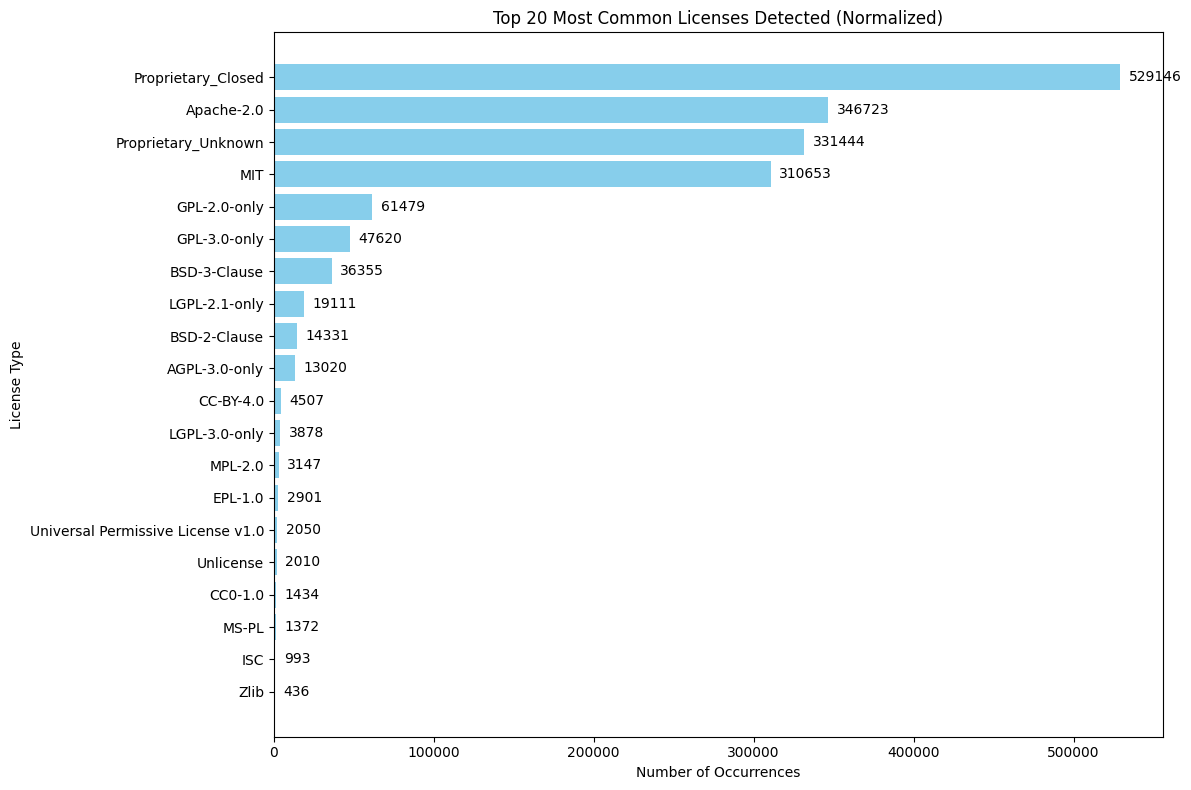

In [34]:
import matplotlib.pyplot as plt
from collections import Counter
from db_operations import get_db_conn
from licenses import license_mapping

def normalize_license(license_name: str) -> str:
    return license_mapping.get(license_name, license_name)

def fetch_license_counts():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch license names from repository_data
    cur.execute("""
        SELECT license
        FROM repository_data
        WHERE license IS NOT NULL AND license <> '';
    """)

    raw_licenses = [row[0].strip() for row in cur.fetchall()]
    cur.close()
    conn.close()

    # Normalize license names
    normalized_licenses = [normalize_license(l) for l in raw_licenses]

    # Count occurrences
    license_counts = Counter(normalized_licenses)
    return license_counts

def plot_license_usage(license_counts, top_n=20):
    # Take top N most common licenses
    most_common = license_counts.most_common(top_n)
    licenses, counts = zip(*most_common)

    plt.figure(figsize=(12, 8))
    plt.barh(licenses[::-1], counts[::-1], color='skyblue')  # Reverse for descending order
    plt.xlabel("Number of Occurrences")
    plt.ylabel("License Type")
    plt.title(f"Top {top_n} Most Common Licenses Detected (Normalized)")

    # Annotate counts on bars
    for i, count in enumerate(counts[::-1]):
        plt.text(count + max(counts)*0.01, i, str(count), va='center')

    plt.tight_layout()
    plt.show()

# Run
license_counts = fetch_license_counts()
plot_license_usage(license_counts, top_n=20)

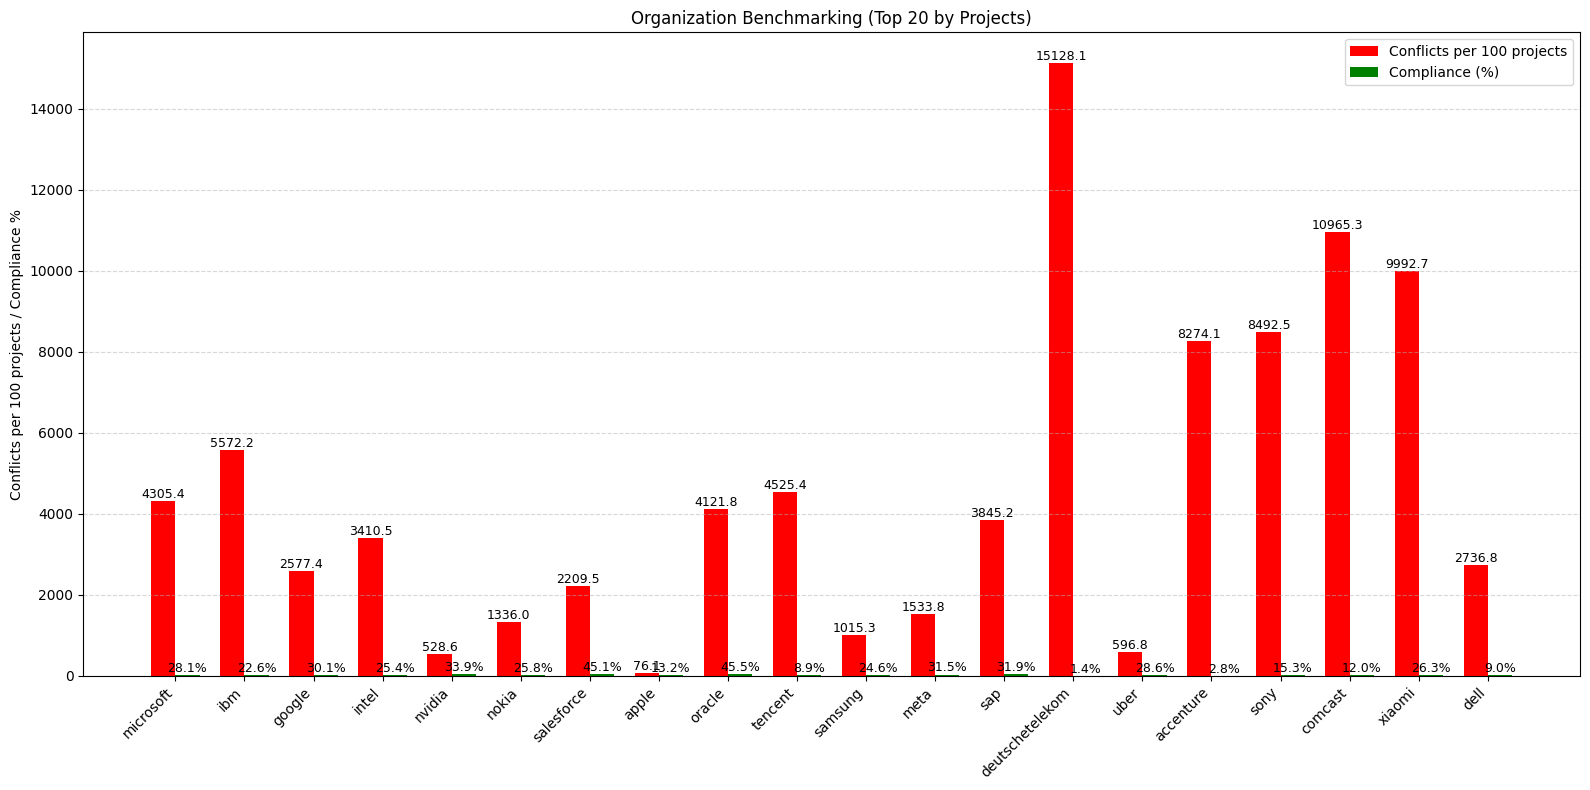

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from db_operations import get_db_conn

def fetch_org_benchmark():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch aggregated data per organization
    cur.execute("""
        SELECT
            LOWER(organization) AS org,
            COUNT(DISTINCT project_id) AS num_projects,
            SUM(same_license) AS same_license,
            SUM(dif_license_comply) AS dif_license_comply,
            SUM(license_conflicts) AS license_conflicts,
            SUM(high_risks) AS high_risks,
            SUM(undetermined) AS undetermined,
            SUM(no_match) AS no_match
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY LOWER(organization);
    """)

    data = []
    for row in cur.fetchall():
        org, num_projects, same, dif, conflicts, high, undet, no_match = row
        total_methods = same + dif + conflicts + high + undet + no_match
        compliant_methods = same + dif
        non_compliant_methods = conflicts + high + undet + no_match
        conflicts_per_100_projects = (conflicts / num_projects) * 100 if num_projects else 0
        compliance_ratio = (compliant_methods / total_methods) if total_methods else 0

        data.append({
            "organization": org,
            "num_projects": num_projects,
            "conflicts_per_100_projects": conflicts_per_100_projects,
            "compliance_ratio": compliance_ratio
        })

    df = pd.DataFrame(data)
    cur.close()
    conn.close()
    return df

def plot_org_benchmark(df, top_n=20):
    # Keep top N organizations by number of projects
    df = df.sort_values("num_projects", ascending=False).head(top_n)
    x = range(len(df))
    width = 0.35

    plt.figure(figsize=(16, 8))

    # Bar chart: Conflicts per 100 projects
    bars_conflicts = plt.bar(x, df["conflicts_per_100_projects"], width=width, label="Conflicts per 100 projects", color="red")

    # Bar chart: Compliance ratio (%)
    bars_compliance = plt.bar([i + width for i in x], df["compliance_ratio"]*100, width=width, label="Compliance (%)", color="green")

    plt.xticks([i + width/2 for i in x], df["organization"], rotation=45, ha='right')
    plt.ylabel("Conflicts per 100 projects / Compliance %")
    plt.title(f"Organization Benchmarking (Top {top_n} by Projects)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Annotate bar values
    for bar in bars_conflicts:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

    for bar in bars_compliance:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


# Run
df_benchmark = fetch_org_benchmark()
plot_org_benchmark(df_benchmark, top_n=20)

/tmp/ipykernel_3857549/1628696967.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(boxplot_data, labels=top_orgs, patch_artist=True, showfliers=True)


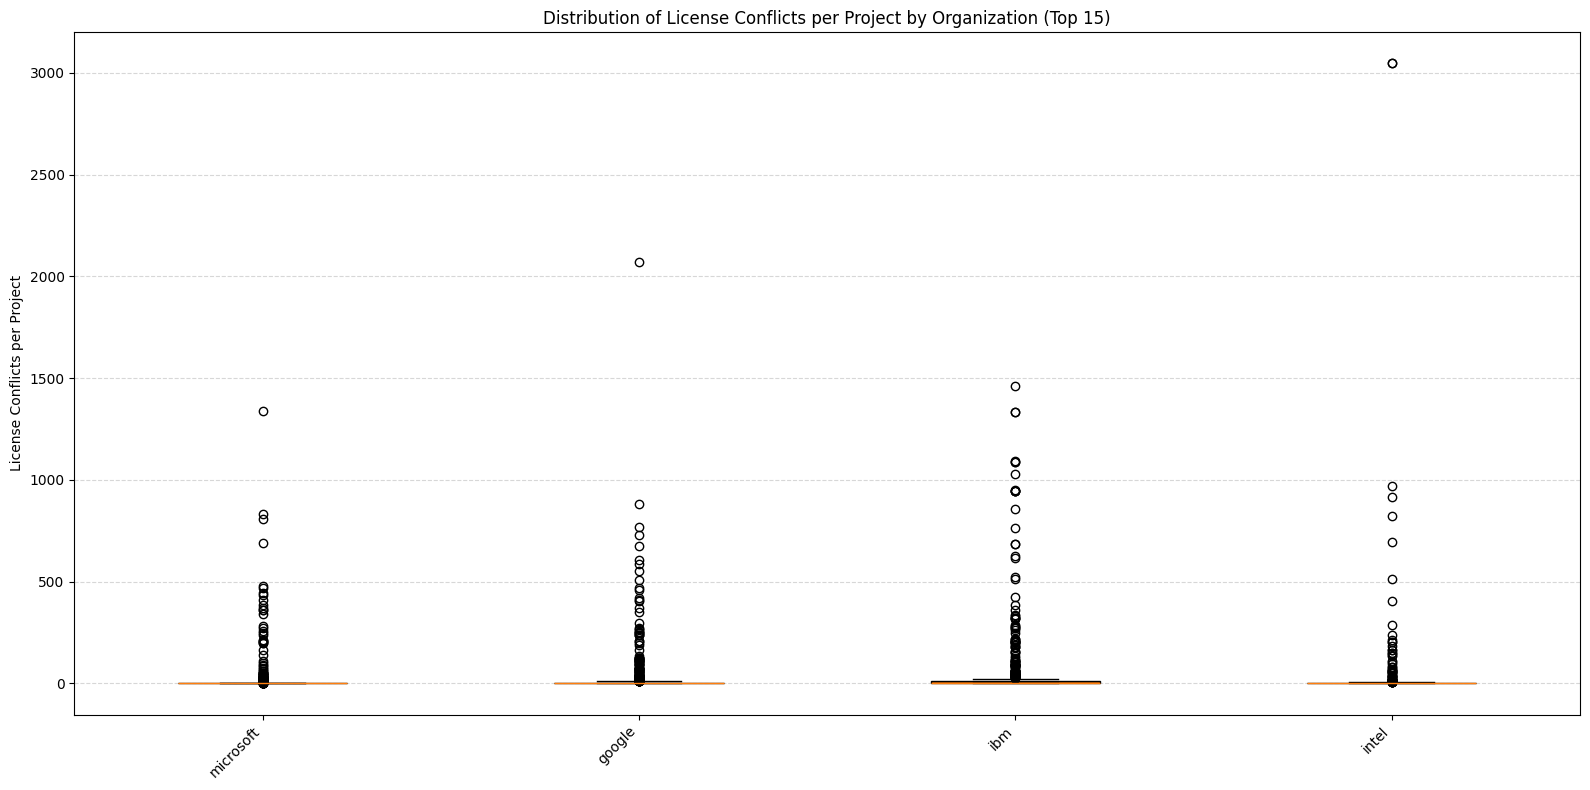

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from db_operations import get_db_conn

def fetch_conflicts_per_project():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch conflicts per project per organization
    cur.execute("""
        SELECT
            LOWER(organization) AS org,
            project_id,
            SUM(license_conflicts) AS conflicts
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY LOWER(organization), project_id;
    """)

    data = []
    for row in cur.fetchall():
        org, project_id, conflicts = row
        data.append({
            "organization": org,
            "project_id": project_id,
            "conflicts": conflicts
        })

    df = pd.DataFrame(data)
    cur.close()
    conn.close()
    return df

def plot_conflicts_boxplot(df, top_n=15):
    # Keep top N organizations by number of projects
    org_counts = df.groupby("organization")["project_id"].nunique().sort_values(ascending=False)
    top_orgs = org_counts.head(top_n).index
    df_top = df[df["organization"].isin(top_orgs)]

    # Prepare data for boxplot: list of conflict counts per organization
    boxplot_data = [df_top[df_top["organization"] == org]["conflicts"].values for org in top_orgs]

    plt.figure(figsize=(16, 8))
    bplot = plt.boxplot(boxplot_data, labels=top_orgs, patch_artist=True, showfliers=True)

    # Color boxes
    colors = plt.cm.tab20.colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    plt.xticks(rotation=45, ha='right')
    plt.ylabel("License Conflicts per Project")
    plt.title(f"Distribution of License Conflicts per Project by Organization (Top {top_n})")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# Run
df_conflicts = fetch_conflicts_per_project()
plot_conflicts_boxplot(df_conflicts, top_n=15)


/tmp/ipykernel_3409745/2110806880.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = plt.boxplot(boxplot_data, labels=top_orgs, patch_artist=True, showfliers=True)


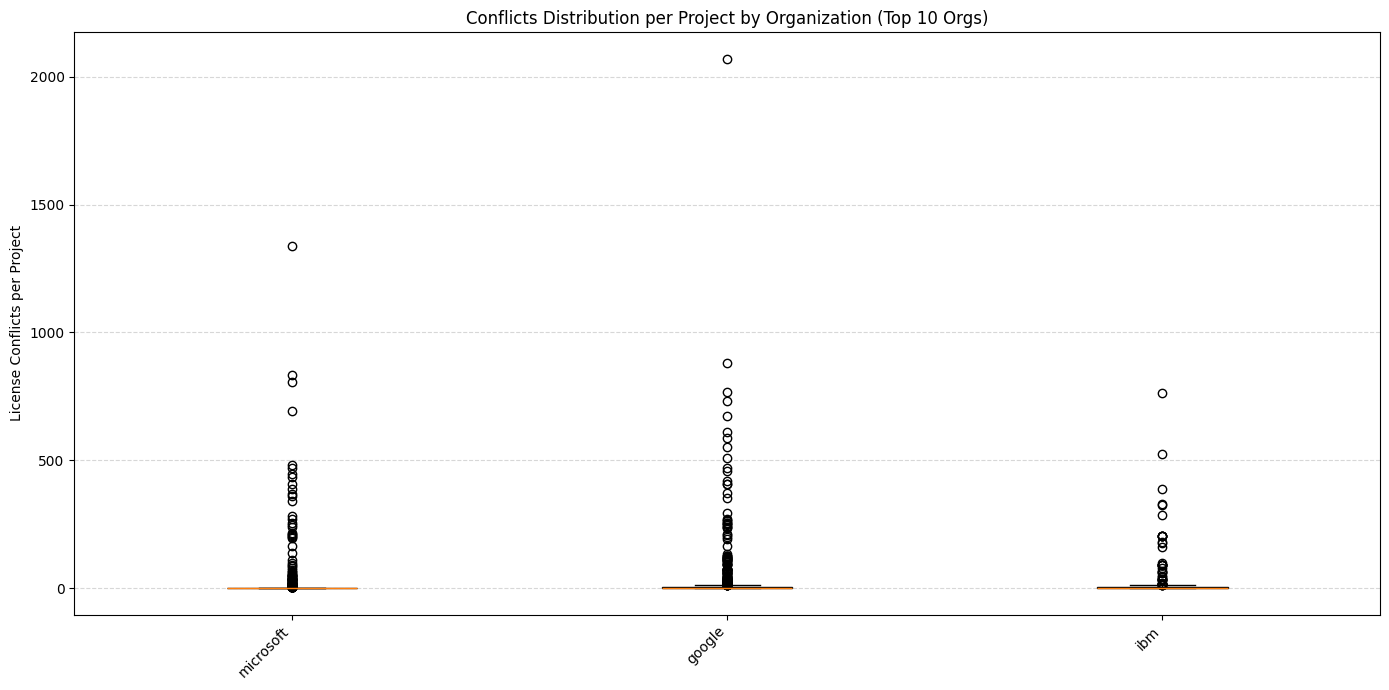

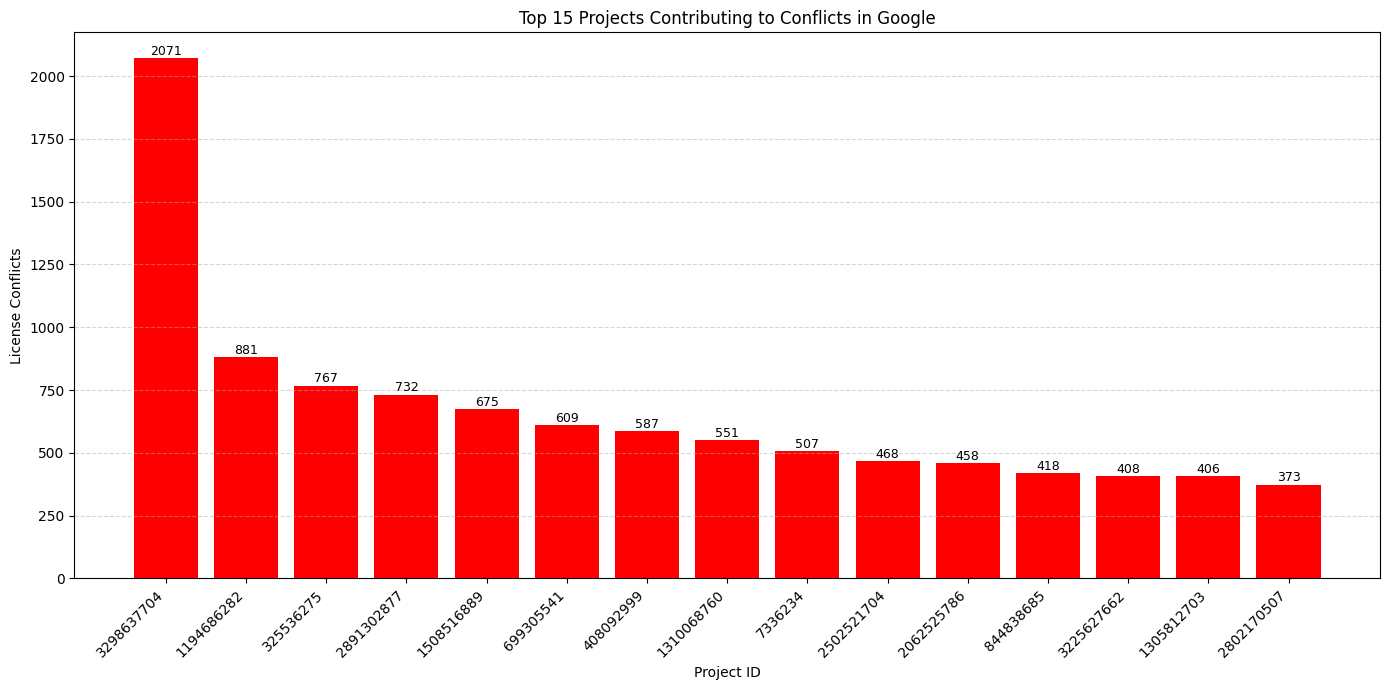

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from db_operations import get_db_conn

def fetch_conflicts():
    conn = get_db_conn()
    cur = conn.cursor()

    # Aggregate conflicts per project per organization
    cur.execute("""
        SELECT
            LOWER(organization) AS org,
            project_id,
            SUM(license_conflicts) AS conflicts
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY LOWER(organization), project_id;
    """)

    rows = cur.fetchall()
    cur.close()
    conn.close()

    return pd.DataFrame(rows, columns=["organization", "project_id", "conflicts"])


def plot_org_boxplot(df, top_n=10):
    # Pick top N orgs by project count
    org_counts = df.groupby("organization")["project_id"].nunique().sort_values(ascending=False)
    top_orgs = org_counts.head(top_n).index
    df_top = df[df["organization"].isin(top_orgs)]

    boxplot_data = [df_top[df_top["organization"] == org]["conflicts"].values for org in top_orgs]

    plt.figure(figsize=(14, 7))
    bplot = plt.boxplot(boxplot_data, labels=top_orgs, patch_artist=True, showfliers=True)

    # Color each box for clarity
    colors = plt.cm.tab20.colors
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("License Conflicts per Project")
    plt.title(f"Conflicts Distribution per Project by Organization (Top {top_n} Orgs)")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_project_breakdown(df, org, top_n=15):
    df_org = df[df["organization"] == org].sort_values(by="conflicts", ascending=False).head(top_n)

    plt.figure(figsize=(14, 7))
    bars = plt.bar(df_org["project_id"], df_org["conflicts"], color="red")

    # Annotate bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height + 1, str(int(height)),
                     ha="center", va="bottom", fontsize=9)

    plt.xticks(rotation=45, ha="right")
    plt.xlabel("Project ID")
    plt.ylabel("License Conflicts")
    plt.title(f"Top {top_n} Projects Contributing to Conflicts in {org.capitalize()}")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


# Run
df_conflicts = fetch_conflicts()

# 1. Overall boxplot by org
plot_org_boxplot(df_conflicts, top_n=10)

# 2. Drill down: pick Google (example)
plot_project_breakdown(df_conflicts, org="google", top_n=15)

/tmp/ipykernel_1795725/3256344407.py:34: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


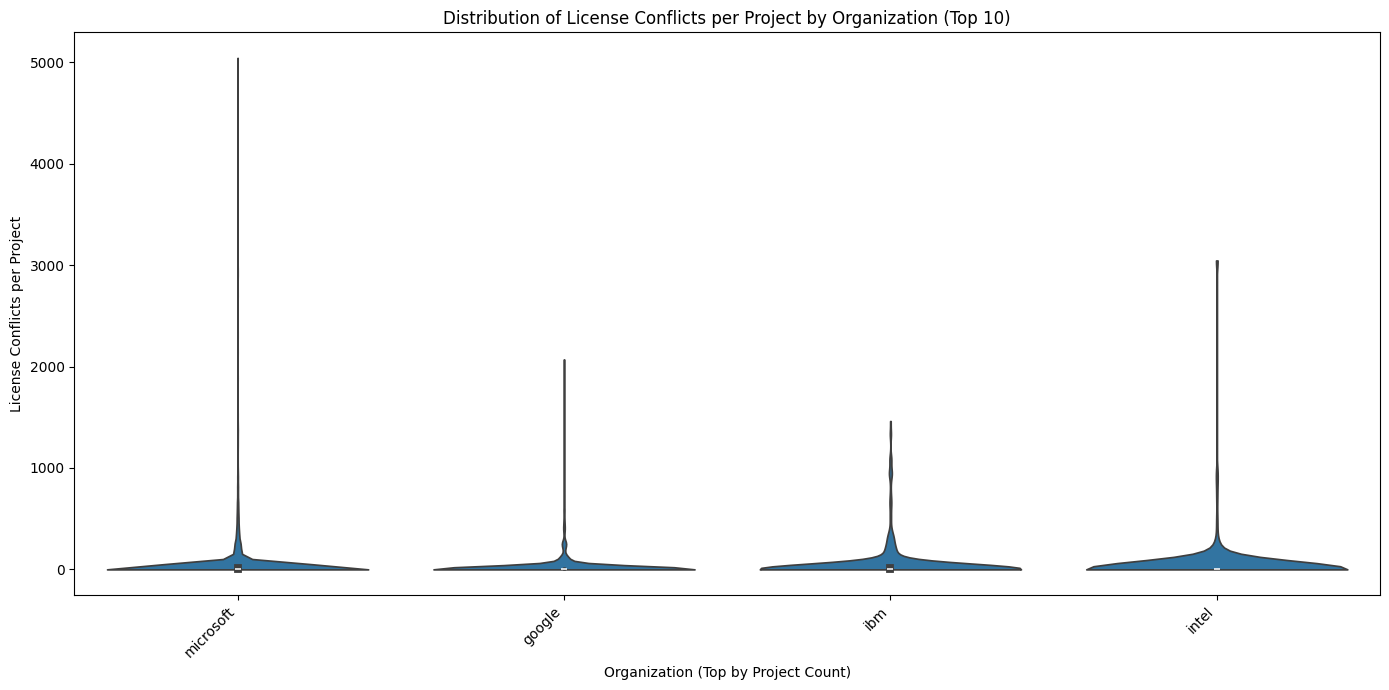

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from db_operations import get_db_conn  # assuming you already have this

def fetch_conflict_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            LOWER(organization) AS organization,
            project_id,
            SUM(license_conflicts) AS conflicts
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY LOWER(organization), project_id;
    """)

    rows = cur.fetchall()
    cur.close()
    conn.close()

    df = pd.DataFrame(rows, columns=["organization", "project_id", "conflicts"])
    return df

def plot_conflict_violin(df, top_n=10):
    # Find top organizations by number of projects
    org_counts = df.groupby("organization")["project_id"].nunique().sort_values(ascending=False)
    top_orgs = org_counts.head(top_n).index
    df_top = df[df["organization"].isin(top_orgs)]

    plt.figure(figsize=(14, 7))
    sns.violinplot(
        data=df_top,
        x="organization",
        y="conflicts",
        cut=0,
        inner="box",   # show mini boxplot inside
        scale="width"  # normalize width for comparability
    )
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("License Conflicts per Project")
    plt.xlabel("Organization (Top by Project Count)")
    plt.title(f"Distribution of License Conflicts per Project by Organization (Top {top_n})")
    plt.tight_layout()
    plt.show()

# Run
df_conflicts = fetch_conflict_data()
plot_conflict_violin(df_conflicts, top_n=10)


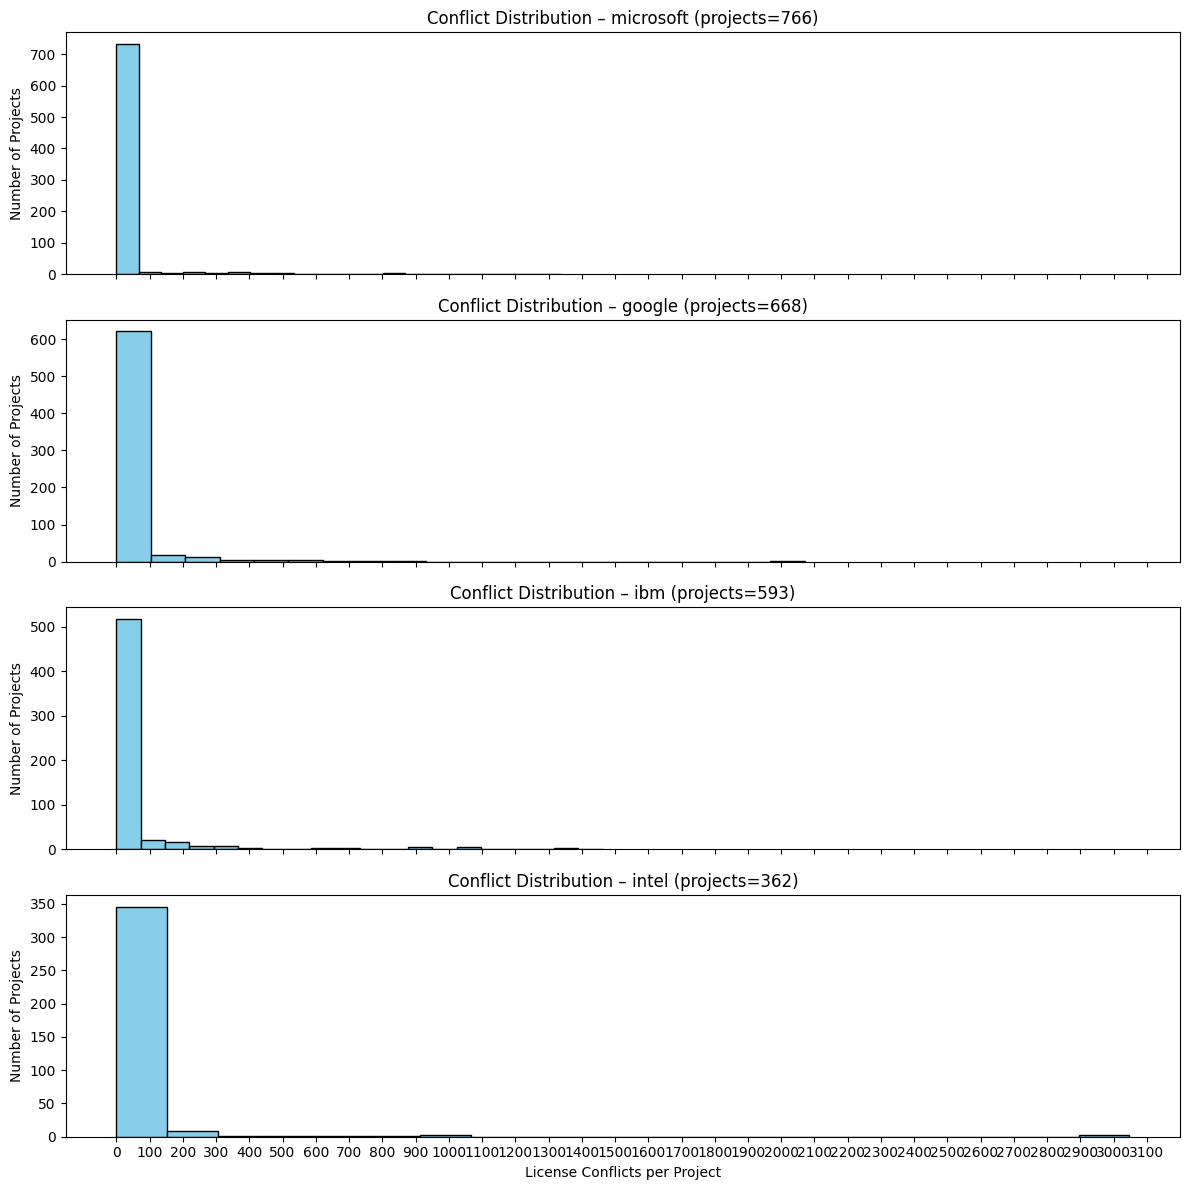

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from db_operations import get_db_conn
import numpy as np

def fetch_conflict_data():
    conn = get_db_conn()
    cur = conn.cursor()

    # Get conflict counts per project
    cur.execute("""
        SELECT
            LOWER(organization) AS org,
            project_id,
            COALESCE(SUM(license_conflicts), 0) AS conflicts
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY LOWER(organization), project_id
        ORDER BY org, conflicts;
    """)

    rows = cur.fetchall()
    cur.close()
    conn.close()

    df = pd.DataFrame(rows, columns=["organization", "project_id", "conflicts"])
    return df


def plot_conflict_histograms(df, top_n=6):
    top_orgs = df["organization"].value_counts().head(top_n).index
    df_top = df[df["organization"].isin(top_orgs)]

    n_orgs = len(top_orgs)
    fig, axes = plt.subplots(n_orgs, 1, figsize=(12, 3*n_orgs), sharex=True)

    if n_orgs == 1:
        axes = [axes]

    for ax, org in zip(axes, top_orgs):
        subset = df_top[df_top["organization"] == org]
        counts, bins, patches = ax.hist(subset["conflicts"], bins=20, color="skyblue", edgecolor="black")

        ax.set_title(f"Conflict Distribution – {org} (projects={len(subset)})")
        ax.set_ylabel("Number of Projects")

        # Set X-axis ticks more frequently (e.g., every 5 conflicts)
        x_min, x_max = ax.get_xlim()
        xticks = np.arange(0, int(x_max)+1, 100)
        ax.set_xticks(xticks)

    axes[-1].set_xlabel("License Conflicts per Project")
    plt.tight_layout()
    plt.show()


# Run
df = fetch_conflict_data()
plot_conflict_histograms(df)

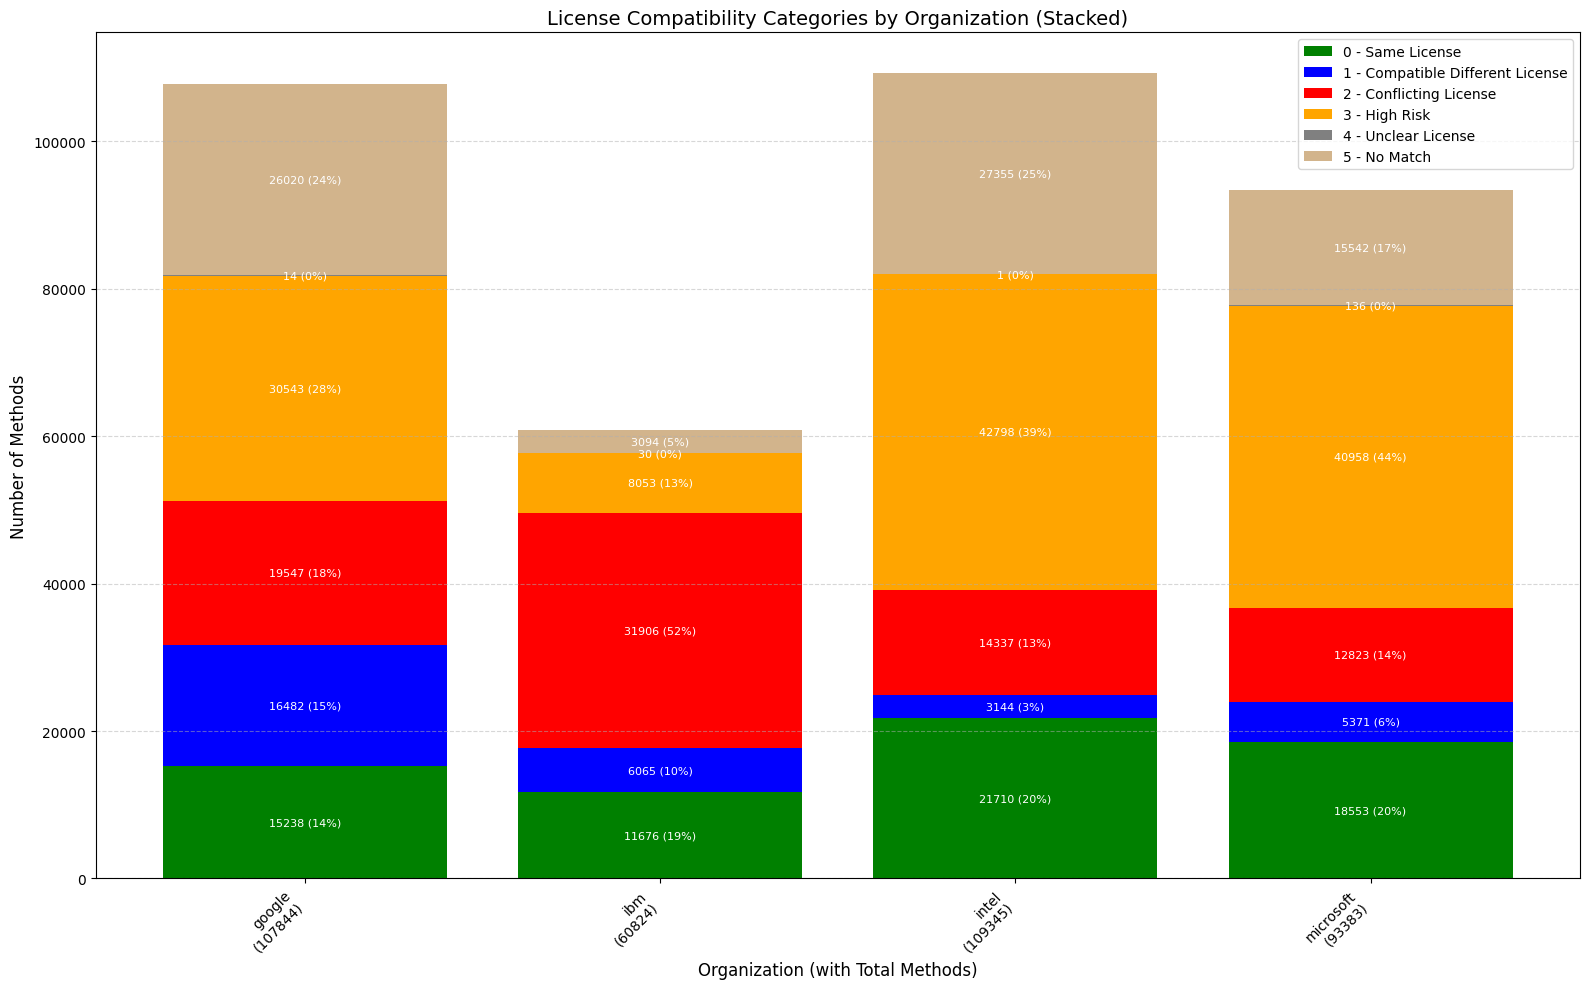

In [8]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn

def fetch_license_category_counts():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            LOWER(organization),
            SUM(same_license) AS cat0,
            SUM(dif_license_comply) AS cat1,
            SUM(license_conflicts) AS cat2,
            SUM(high_risks) AS cat3,
            SUM(undetermined) AS cat4,
            SUM(no_match) AS cat5,
            (
                COALESCE(SUM(same_license), 0) +
                COALESCE(SUM(dif_license_comply), 0) +
                COALESCE(SUM(license_conflicts), 0) +
                COALESCE(SUM(high_risks), 0) +
                COALESCE(SUM(undetermined), 0) +
                COALESCE(SUM(no_match), 0)
            ) AS total_methods
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
        GROUP BY LOWER(organization);
    """)

    company_category_data = {}
    for row in cur.fetchall():
        org = row[0]
        company_category_data[org] = {
            0: row[1] or 0,
            1: row[2] or 0,
            2: row[3] or 0,
            3: row[4] or 0,
            4: row[5] or 0,
            5: row[6] or 0,
            'total_methods': row[7] or 0
        }

    cur.close()
    conn.close()
    return company_category_data

def plot_license_categories_stacked(company_category_data):
    companies = sorted(company_category_data.keys())
    x = range(len(companies))

    # Extract data per category
    category_0 = [company_category_data[c][0] for c in companies]
    category_1 = [company_category_data[c][1] for c in companies]
    category_2 = [company_category_data[c][2] for c in companies]
    category_3 = [company_category_data[c][3] for c in companies]
    category_4 = [company_category_data[c][4] for c in companies]
    category_5 = [company_category_data[c][5] for c in companies]
    total_methods = [company_category_data[c]['total_methods'] for c in companies]

    # Append total_methods to company labels
    labels = [f"{c}\n({total_methods[i]})" for i, c in enumerate(companies)]

    plt.figure(figsize=(16, 10))

    # Create stacked bars
    p0 = plt.bar(x, category_0, label='0 - Same License', color='green')
    p1 = plt.bar(x, category_1, bottom=category_0, label='1 - Compatible Different License', color='blue')
    p2 = plt.bar(x, category_2, bottom=[i+j for i,j in zip(category_0, category_1)], label='2 - Conflicting License', color='red')
    p3 = plt.bar(x, category_3, bottom=[i+j+k for i,j,k in zip(category_0, category_1, category_2)], label='3 - High Risk', color='orange')
    p4 = plt.bar(x, category_4, bottom=[i+j+k+l for i,j,k,l in zip(category_0, category_1, category_2, category_3)], label='4 - Unclear License', color='gray')
    p5 = plt.bar(x, category_5, bottom=[i+j+k+l+m for i,j,k,l,m in zip(category_0, category_1, category_2, category_3, category_4)], label='5 - No Match', color='tan')

    # Annotate bars with "number (percentage%)"
    for i in x:
        cum_height = 0
        for cat_height in [category_0[i], category_1[i], category_2[i], category_3[i], category_4[i], category_5[i]]:
            if total_methods[i] > 0 and cat_height > 0:
                pct = cat_height / total_methods[i] * 100
                plt.text(i, cum_height + cat_height/2,
                         f'{cat_height} ({pct:.0f}%)',
                         ha='center', va='center', color='white', fontsize=8)
            cum_height += cat_height

    plt.xlabel('Organization (with Total Methods)', fontsize=12)
    plt.ylabel('Number of Methods', fontsize=12)
    plt.title('License Compatibility Categories by Organization (Stacked)', fontsize=14)
    plt.xticks(x, labels, rotation=45, ha='right')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    company_category_data = fetch_license_category_counts()
    if company_category_data:
        plot_license_categories_stacked(company_category_data)
    else:
        print("No data found.")


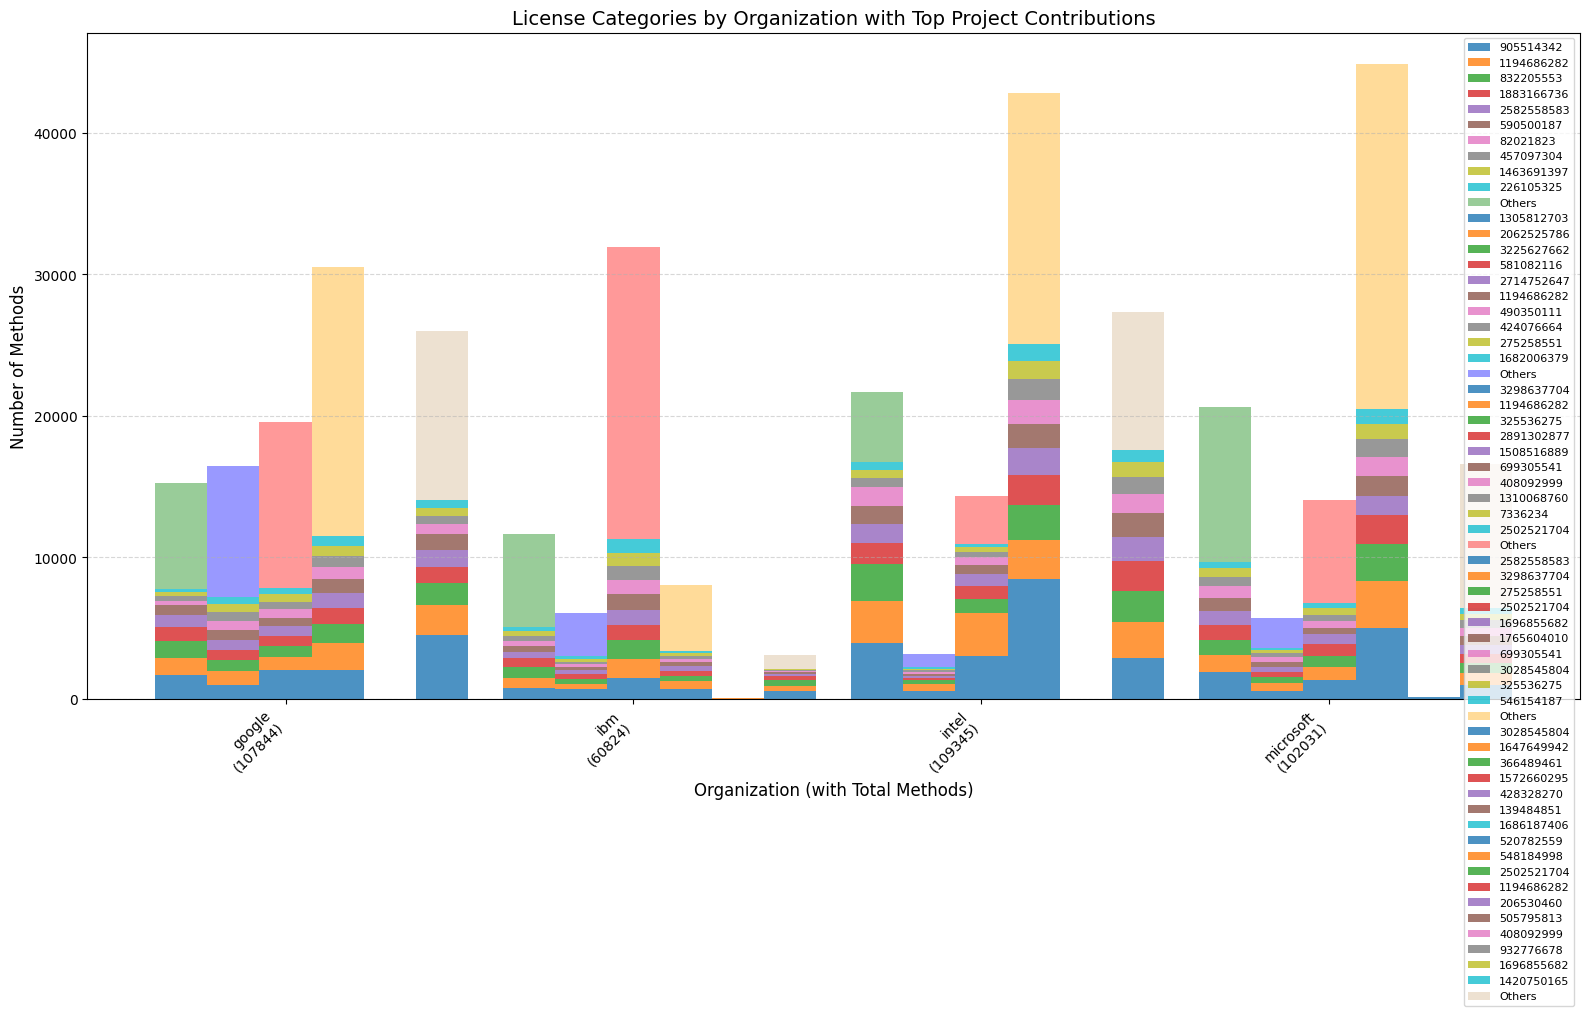

In [21]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn
import numpy as np

TOP_N_PROJECTS = 10  # number of top projects to highlight per bar

def fetch_license_category_counts_with_projects():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch per-project counts
    cur.execute("""
        SELECT
            LOWER(organization),
            project_id,
            same_license,
            dif_license_comply,
            license_conflicts,
            high_risks,
            undetermined,
            no_match
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = {}
    for row in cur.fetchall():
        org = row[0]
        project_id = row[1]
        if org not in data:
            data[org] = {0: [], 1: [], 2: [], 3: [], 4: [], 5: []}
        for cat in range(6):
            data[org][cat].append((project_id, row[2+cat] or 0))

    cur.close()
    conn.close()
    return data

def plot_license_categories_with_projects(data):
    companies = sorted(data.keys())
    x = np.arange(len(companies))
    width = 0.15

    category_labels = [
        '0 - Same License', '1 - Compatible Different License',
        '2 - Conflicting License', '3 - High Risk',
        '4 - Unclear License', '5 - No Match'
    ]
    base_colors = ['green', 'blue', 'red', 'orange', 'gray', 'tan']

    plt.figure(figsize=(16, 10))

    for cat in range(6):
        bottoms = np.zeros(len(companies))
        bars_list = []
        for org_idx, org in enumerate(companies):
            # sort projects by contribution descending
            projects = sorted(data[org][cat], key=lambda x: x[1], reverse=True)
            # pick top N
            top_projects = projects[:TOP_N_PROJECTS]
            other_total = sum([p[1] for p in projects[TOP_N_PROJECTS:]])
            # add each top project as a segment
            for proj_id, count in top_projects:
                bar = plt.bar(
                    x[org_idx] + (cat-2)*width, count, width=width,
                    bottom=bottoms[org_idx], label=f'{proj_id}' if org_idx==0 else "", alpha=0.8
                )
                bottoms[org_idx] += count
            # add remaining as "Others"
            if other_total > 0:
                bar = plt.bar(
                    x[org_idx] + (cat-2)*width, other_total, width=width,
                    bottom=bottoms[org_idx], color=base_colors[cat], alpha=0.4,
                    label='Others' if org_idx==0 else ""
                )
                bottoms[org_idx] += other_total

    # append total counts to labels
    total_methods = [sum([c[1] for c in sum([data[org][cat] for cat in range(6)], [])]) for org in companies]
    labels = [f"{c}\n({total_methods[i]})" for i, c in enumerate(companies)]

    plt.xticks(x, labels, rotation=45, ha='right')
    plt.xlabel('Organization (with Total Methods)', fontsize=12)
    plt.ylabel('Number of Methods', fontsize=12)
    plt.title('License Categories by Organization with Top Project Contributions', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    data = fetch_license_category_counts_with_projects()
    plot_license_categories_with_projects(data)


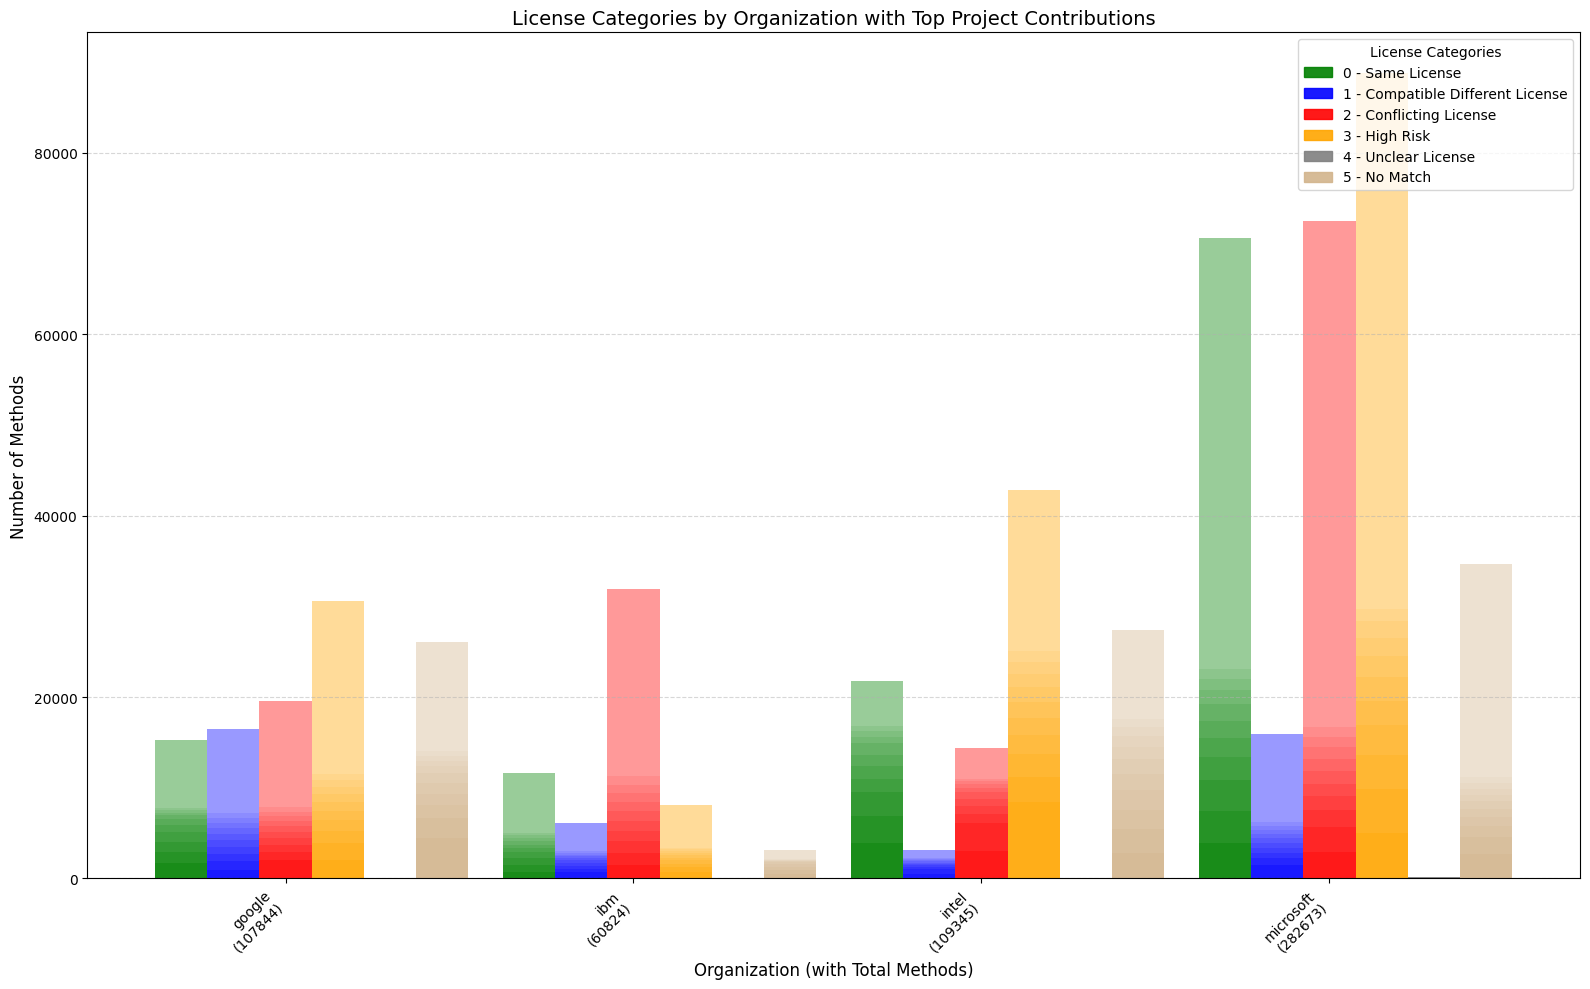

In [4]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn
import numpy as np

TOP_N_PROJECTS = 10  # number of top projects to highlight per bar

def fetch_license_category_counts_with_projects():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch per-project counts
    cur.execute("""
        SELECT
            LOWER(organization),
            project_id,
            same_license,
            dif_license_comply,
            license_conflicts,
            high_risks,
            undetermined,
            no_match
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = {}
    for row in cur.fetchall():
        org = row[0]
        project_id = row[1]
        if org not in data:
            data[org] = {0: [], 1: [], 2: [], 3: [], 4: [], 5: []}
        for cat in range(6):
            data[org][cat].append((project_id, row[2+cat] or 0))

    cur.close()
    conn.close()
    return data

def plot_license_categories_with_projects(data):
    companies = sorted(data.keys())
    x = np.arange(len(companies))
    width = 0.15

    category_labels = [
        '0 - Same License', '1 - Compatible Different License',
        '2 - Conflicting License', '3 - High Risk',
        '4 - Unclear License', '5 - No Match'
    ]
    base_colors = ['green', 'blue', 'red', 'orange', 'gray', 'tan']

    plt.figure(figsize=(16, 10))

    for cat in range(6):
        bottoms = np.zeros(len(companies))
        for org_idx, org in enumerate(companies):
            # sort projects by contribution descending
            projects = sorted(data[org][cat], key=lambda x: x[1], reverse=True)
            top_projects = projects[:TOP_N_PROJECTS]
            other_total = sum([p[1] for p in projects[TOP_N_PROJECTS:]])
            # color gradient for top projects
            for idx, (proj_id, count) in enumerate(top_projects):
                alpha = 0.9 - (idx / TOP_N_PROJECTS) * 0.5  # slightly transparent
                plt.bar(
                    x[org_idx] + (cat-2)*width, count, width=width,
                    bottom=bottoms[org_idx], color=base_colors[cat], alpha=alpha
                )
                bottoms[org_idx] += count
            # remaining projects as "Others"
            if other_total > 0:
                plt.bar(
                    x[org_idx] + (cat-2)*width, other_total, width=width,
                    bottom=bottoms[org_idx], color=base_colors[cat], alpha=0.4
                )
                bottoms[org_idx] += other_total

    # append total counts to labels
    total_methods = [sum([c[1] for c in sum([data[org][cat] for cat in range(6)], [])]) for org in companies]
    labels = [f"{c}\n({total_methods[i]})" for i, c in enumerate(companies)]

    plt.xticks(x, labels, rotation=45, ha='right')
    plt.xlabel('Organization (with Total Methods)', fontsize=12)
    plt.ylabel('Number of Methods', fontsize=12)
    plt.title('License Categories by Organization with Top Project Contributions', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Legend for categories
    category_patches = [plt.Rectangle((0,0),1,1,color=base_colors[i], alpha=0.9) for i in range(6)]
    plt.legend(category_patches, category_labels, title='License Categories', loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    data = fetch_license_category_counts_with_projects()
    plot_license_categories_with_projects(data)


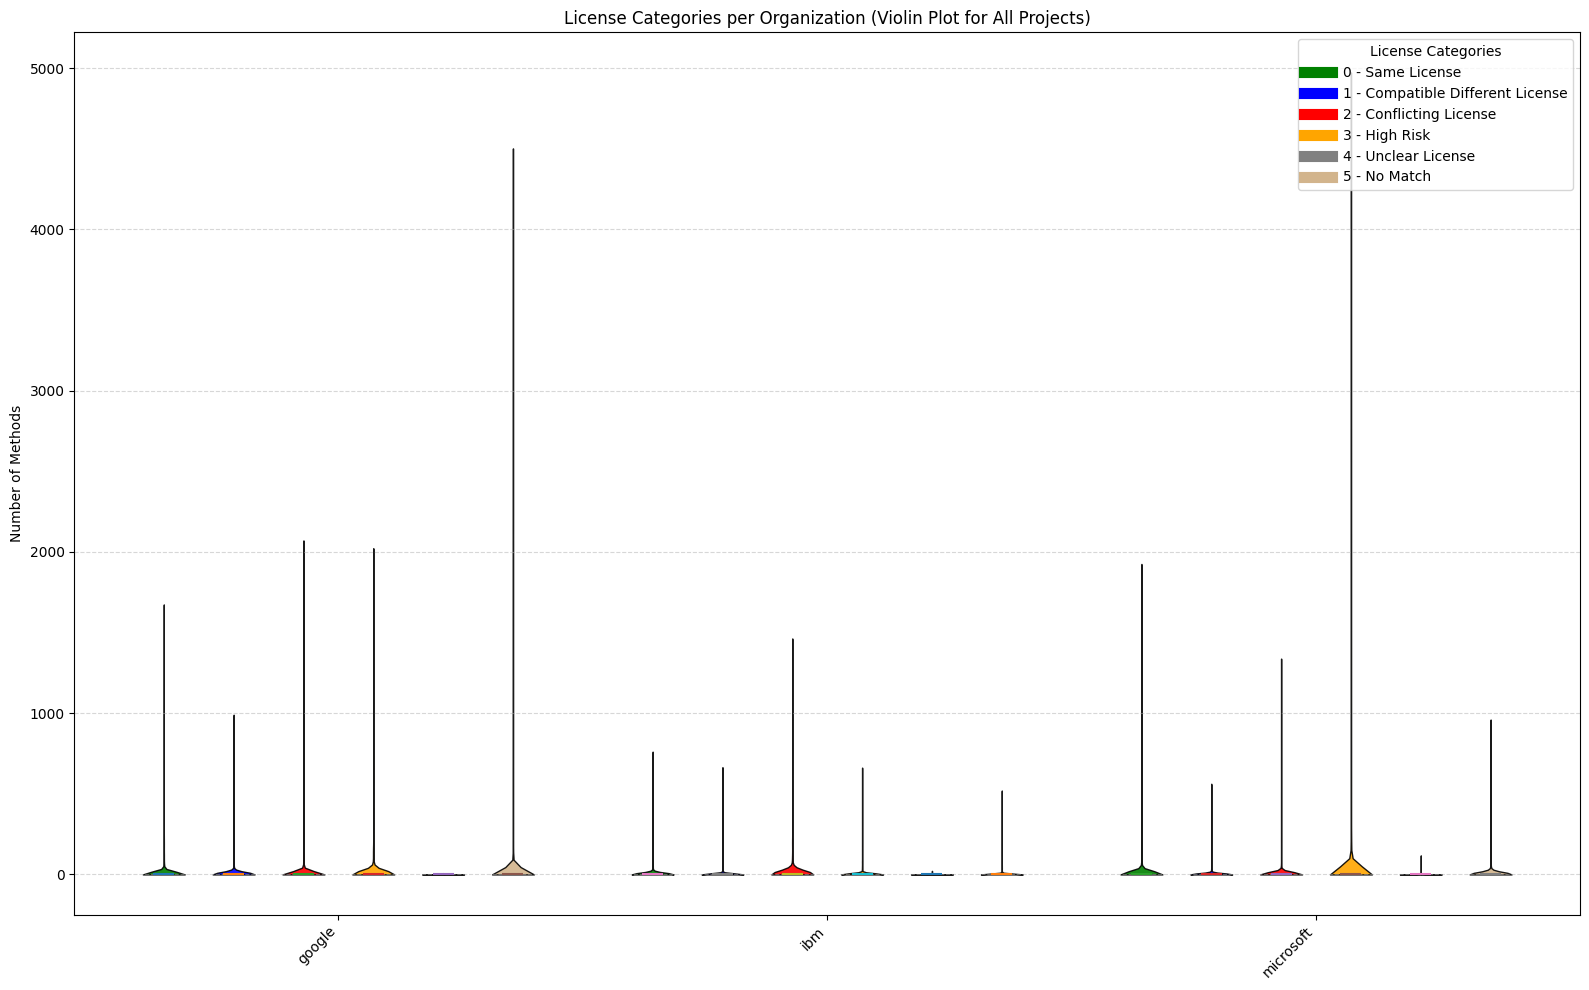

In [9]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn
import numpy as np

CATEGORY_LABELS = [
    '0 - Same License', '1 - Compatible Different License',
    '2 - Conflicting License', '3 - High Risk',
    '4 - Unclear License', '5 - No Match'
]

CATEGORY_COLORS = ['green', 'blue', 'red', 'orange', 'gray', 'tan']

def fetch_license_project_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            LOWER(organization) as org,
            project_id,
            same_license,
            dif_license_comply,
            license_conflicts,
            high_risks,
            undetermined,
            no_match
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = {}
    for row in cur.fetchall():
        org = row[0]
        if org not in data:
            data[org] = {i: [] for i in range(6)}
        for cat in range(6):
            data[org][cat].append(row[2 + cat] or 0)
    cur.close()
    conn.close()
    return data

def plot_violin_by_org(data):
    orgs = sorted(data.keys())
    n_orgs = len(orgs)
    n_cats = 6
    violin_width = 0.6
    org_spacing = n_cats + 1.0

    plt.figure(figsize=(16, 10))

    for org_idx, org in enumerate(orgs):
        x_center = np.arange(n_cats) + org_idx * org_spacing
        for cat in range(n_cats):
            values = data[org][cat]
            if len(values) == 0:
                continue
            # plot violin for all projects
            parts = plt.violinplot(values, positions=[x_center[cat]], widths=violin_width,
                                   showmeans=False, showmedians=True, showextrema=False)
            for pc in parts['bodies']:
                pc.set_facecolor(CATEGORY_COLORS[cat])
                pc.set_edgecolor('black')
                pc.set_alpha(0.9)

    # X-axis labels centered per organization
    tick_positions = [org_idx*org_spacing + (n_cats-1)/2 for org_idx in range(n_orgs)]
    plt.xticks(tick_positions, [f"{org}" for org in orgs], rotation=45, ha='right')

    # Legend for categories
    category_patches = [plt.Line2D([0], [0], color=CATEGORY_COLORS[i], lw=8) for i in range(n_cats)]
    plt.legend(category_patches, CATEGORY_LABELS, title='License Categories', loc='upper right', fontsize=10)

    plt.ylabel('Number of Methods')
    plt.title('License Categories per Organization (Violin Plot for All Projects)')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    data = fetch_license_project_data()
    plot_violin_by_org(data)


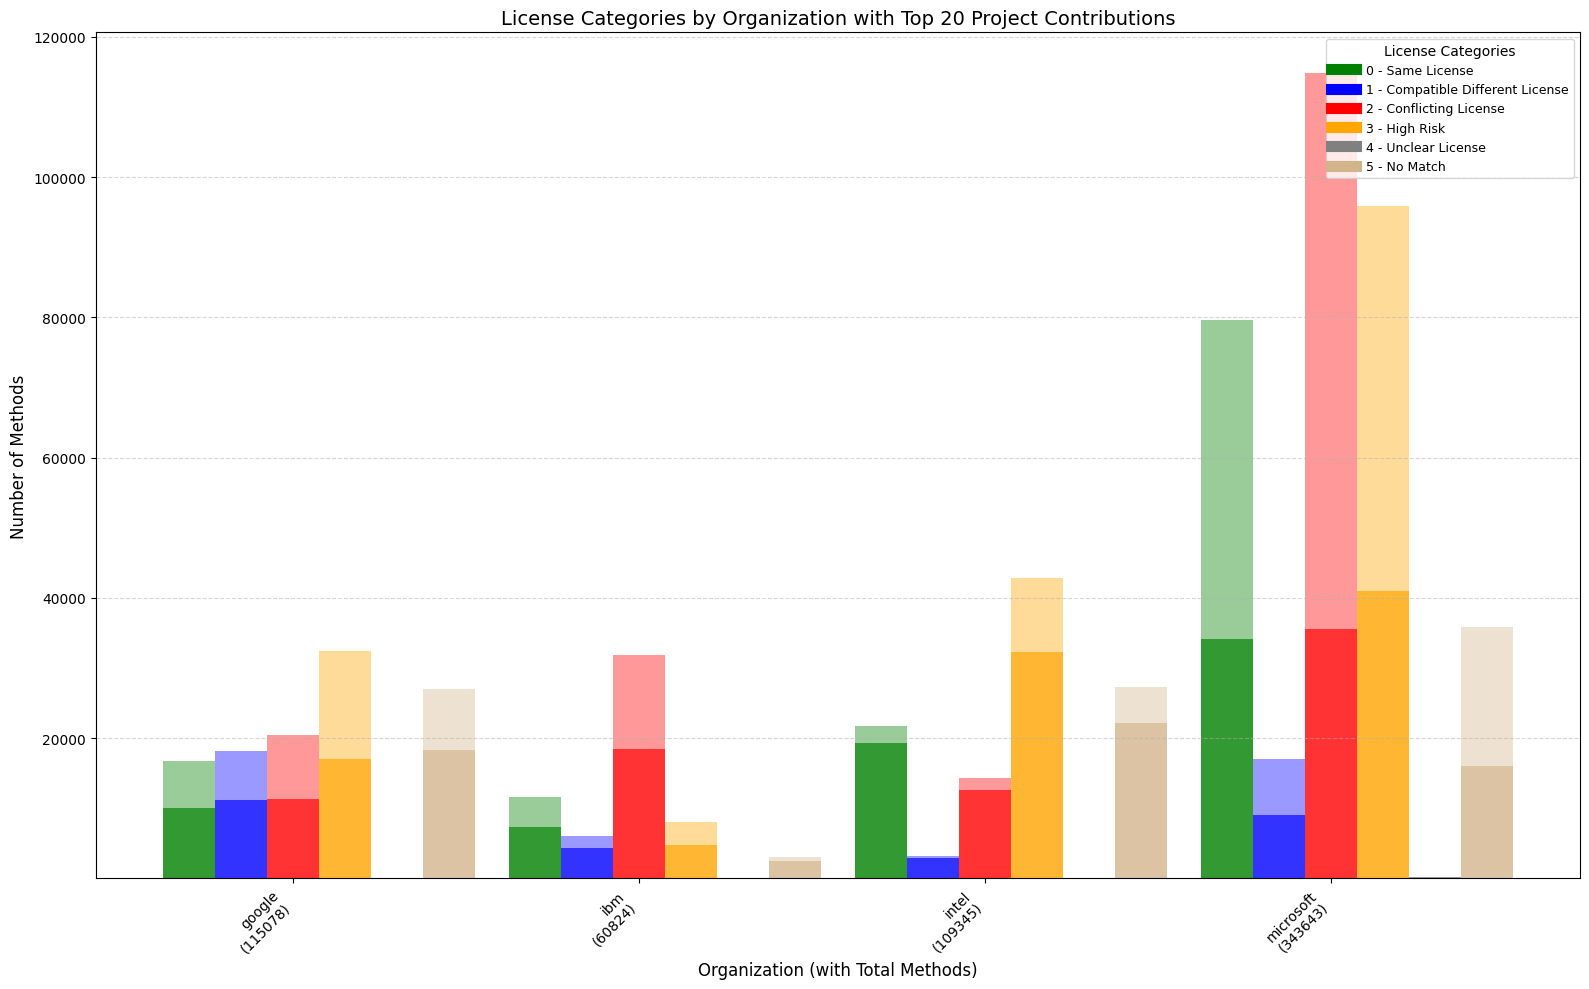

In [2]:
import matplotlib.pyplot as plt
from db_operations import get_db_conn
import numpy as np

TOP_N_PROJECTS = 20  # number of top projects to highlight per bar

def fetch_license_category_counts_with_projects():
    conn = get_db_conn()
    cur = conn.cursor()

    # Fetch per-project counts
    cur.execute("""
        SELECT
            LOWER(organization),
            project_id,
            same_license,
            dif_license_comply,
            license_conflicts,
            high_risks,
            undetermined,
            no_match
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = {}
    for row in cur.fetchall():
        org = row[0]
        project_id = row[1]
        if org not in data:
            data[org] = {0: [], 1: [], 2: [], 3: [], 4: [], 5: []}
        for cat in range(6):
            data[org][cat].append((project_id, row[2+cat] or 0))

    cur.close()
    conn.close()
    return data

def plot_license_categories_with_projects(data):
    companies = sorted(data.keys())
    x = np.arange(len(companies))
    width = 0.15

    category_labels = [
        '0 - Same License', 
        '1 - Compatible Different License',
        '2 - Conflicting License', 
        '3 - High Risk',
        '4 - Unclear License', 
        '5 - No Match'
    ]
    base_colors = ['green', 'blue', 'red', 'orange', 'gray', 'tan']

    plt.figure(figsize=(16, 10))

    for cat in range(6):
        bottoms = np.zeros(len(companies))
        for org_idx, org in enumerate(companies):
            # sort projects by contribution descending
            projects = sorted(data[org][cat], key=lambda x: x[1], reverse=True)
            # pick top N
            top_projects = projects[:TOP_N_PROJECTS]
            other_total = sum([p[1] for p in projects[TOP_N_PROJECTS:]])

            # add each top project as a segment
            for proj_id, count in top_projects:
                plt.bar(
                    x[org_idx] + (cat-2)*width, count, width=width,
                    bottom=bottoms[org_idx], alpha=0.8,
                    color=base_colors[cat]
                )
                bottoms[org_idx] += count

            # add remaining as "Others"
            if other_total > 0:
                plt.bar(
                    x[org_idx] + (cat-2)*width, other_total, width=width,
                    bottom=bottoms[org_idx], color=base_colors[cat], alpha=0.4
                )
                bottoms[org_idx] += other_total

    # append total counts to labels
    total_methods = [
        sum([c[1] for c in sum([data[org][cat] for cat in range(6)], [])]) 
        for org in companies
    ]
    labels = [f"{c}\n({total_methods[i]})" for i, c in enumerate(companies)]

    plt.xticks(x, labels, rotation=45, ha='right')
    plt.xlabel('Organization (with Total Methods)', fontsize=12)
    plt.ylabel('Number of Methods', fontsize=12)
    plt.title('License Categories by Organization with Top 20 Project Contributions', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # ---- Custom category legend ----
    category_patches = [plt.Line2D([0], [0], color=base_colors[i], lw=8) for i in range(6)]
    plt.legend(category_patches, category_labels, title="License Categories", loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    data = fetch_license_category_counts_with_projects()
    plot_license_categories_with_projects(data)

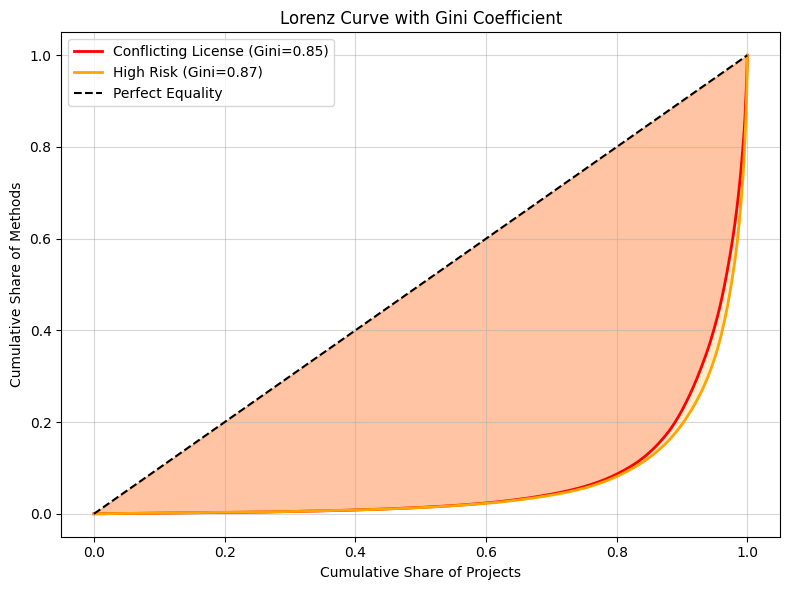

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from db_operations import get_db_conn

def fetch_conflict_highrisk_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            LOWER(organization),
            project_id,
            license_conflicts,
            high_risks
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = {"conflict": [], "highrisk": []}
    for row in cur.fetchall():
        org = row[0]
        proj = row[1]
        conflicts = row[2] or 0
        highrisk = row[3] or 0
        if conflicts > 0:
            data["conflict"].append((org, proj, conflicts))
        if highrisk > 0:
            data["highrisk"].append((org, proj, highrisk))

    cur.close()
    conn.close()
    return data

def gini_coefficient(values):
    """Compute Gini coefficient for a numpy array of positive values"""
    values = np.sort(values)
    n = len(values)
    cumvals = np.cumsum(values)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

def plot_lorenz_with_gini(data, label, color):
    values = np.array([d[2] for d in data])
    values = np.sort(values)
    n = len(values)

    cum_projects = np.arange(1, n+1) / n
    cum_values = np.cumsum(values) / values.sum()
    cum_projects = np.insert(cum_projects, 0, 0)
    cum_values = np.insert(cum_values, 0, 0)

    gini = gini_coefficient(values)
    plt.plot(cum_projects, cum_values, label=f"{label} (Gini={gini:.2f})", color=color, lw=2)
    plt.fill_between(cum_projects, cum_values, cum_projects, color=color, alpha=0.2)

if __name__ == "__main__":
    data = fetch_conflict_highrisk_data()

    plt.figure(figsize=(8, 6))
    plot_lorenz_with_gini(data["conflict"], "Conflicting License", "red")
    plot_lorenz_with_gini(data["highrisk"], "High Risk", "orange")

    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Equality")
    plt.xlabel("Cumulative Share of Projects")
    plt.ylabel("Cumulative Share of Methods")
    plt.title("Lorenz Curve with Gini Coefficient")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()

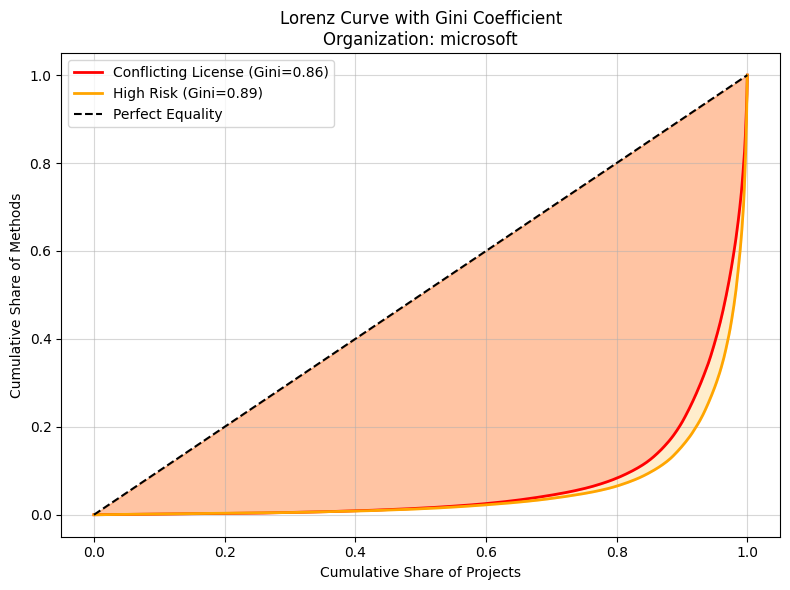

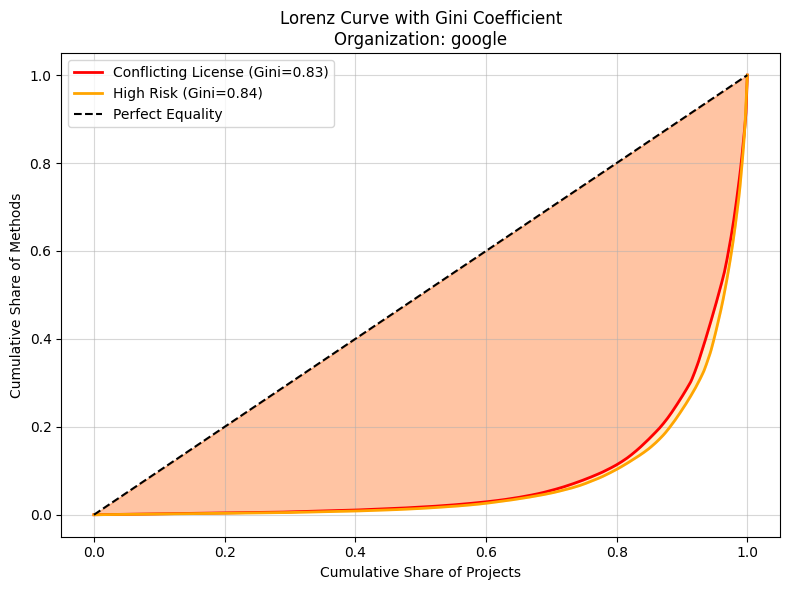

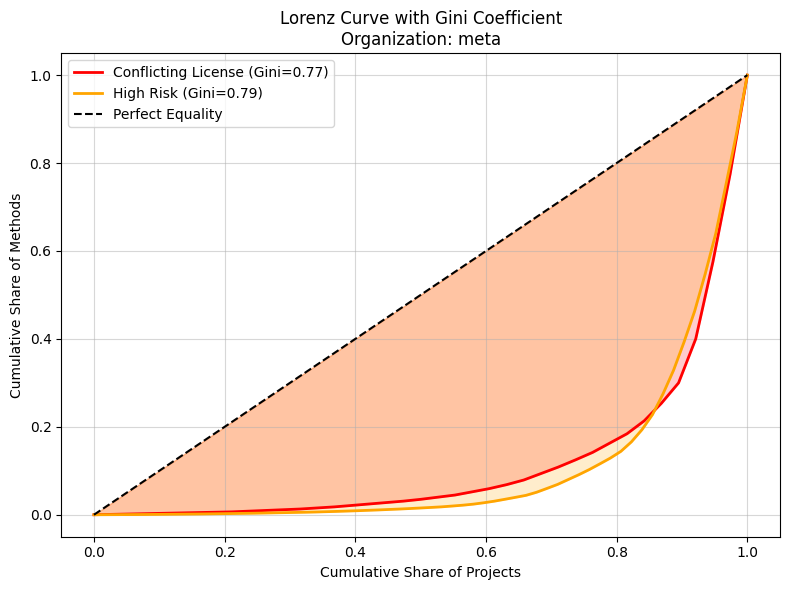

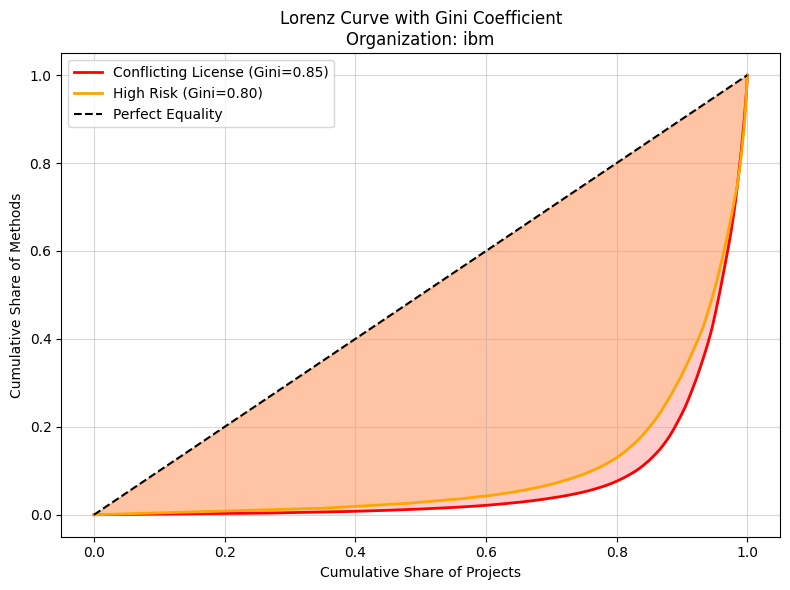

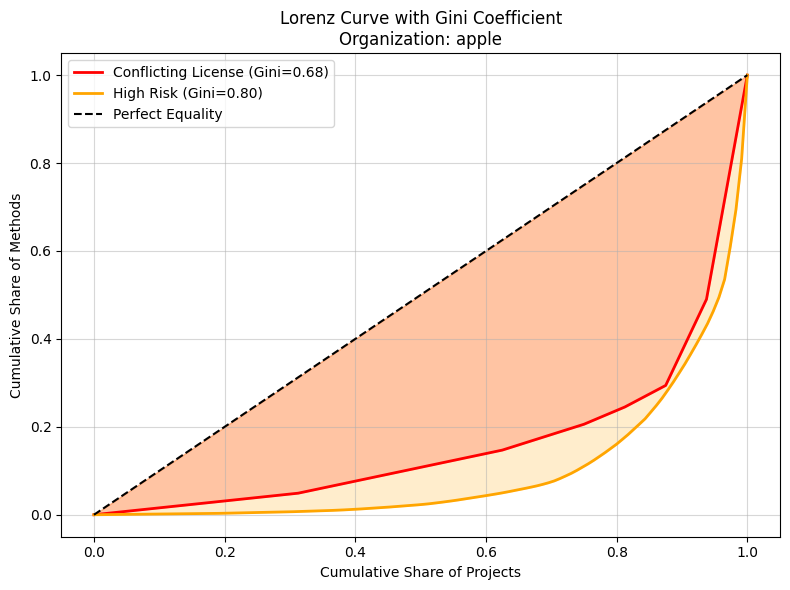

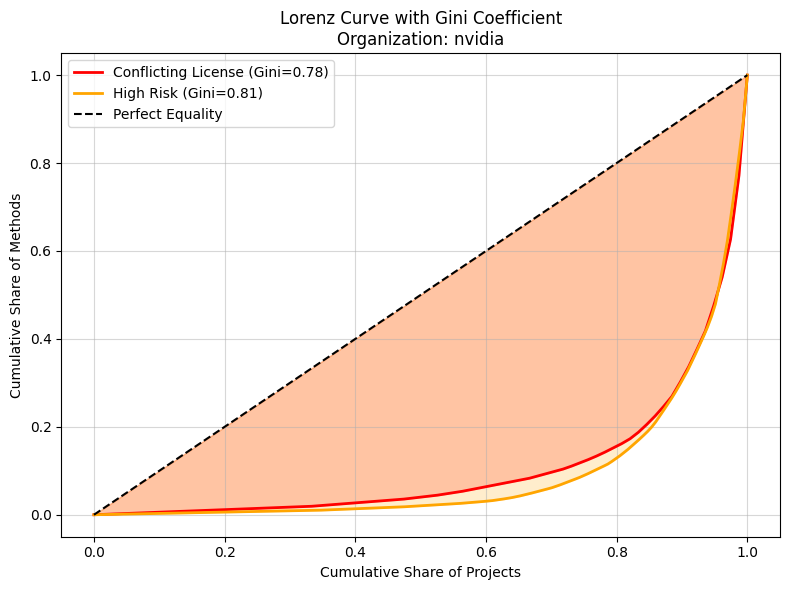

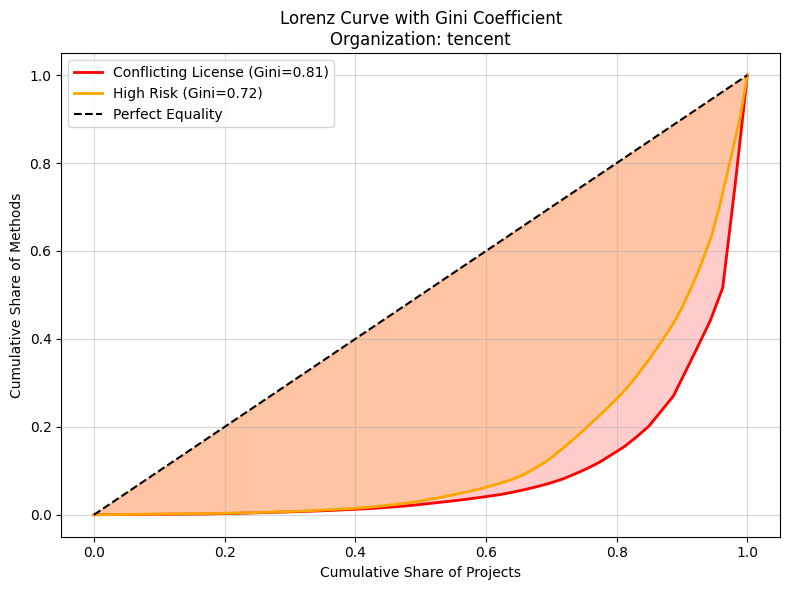

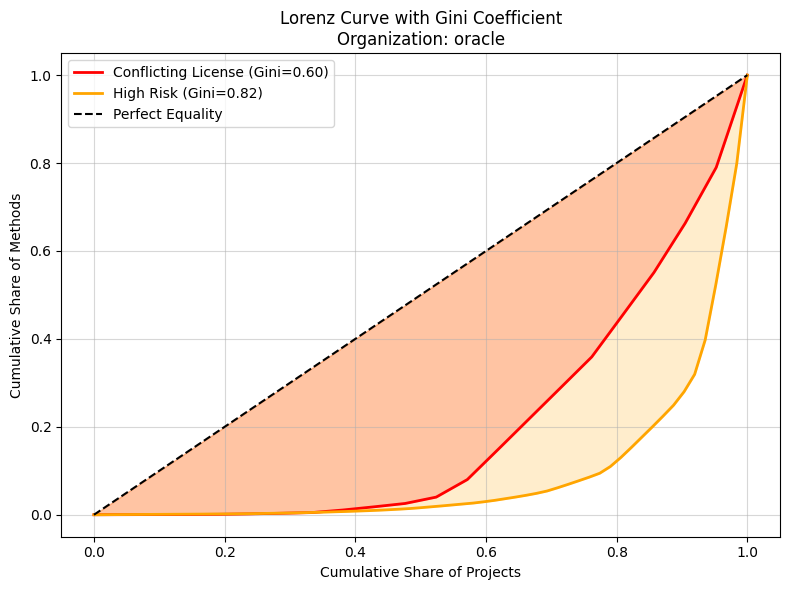

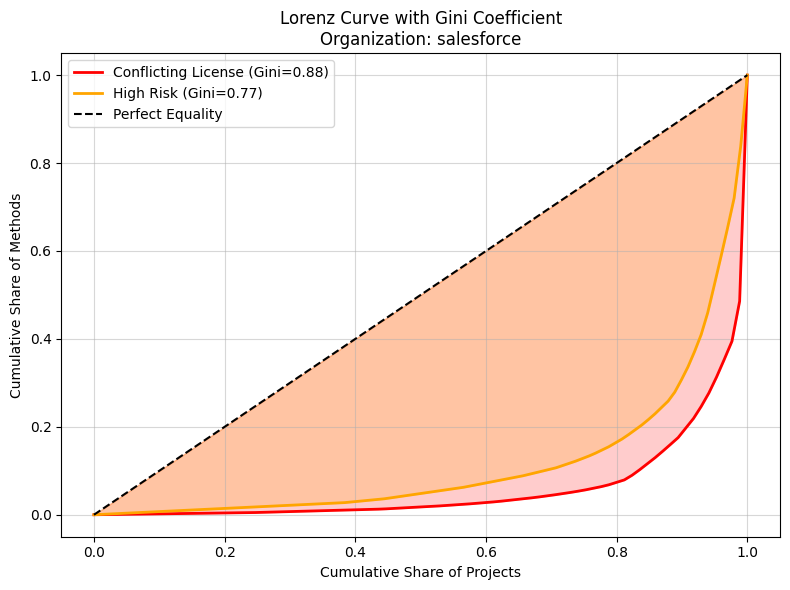

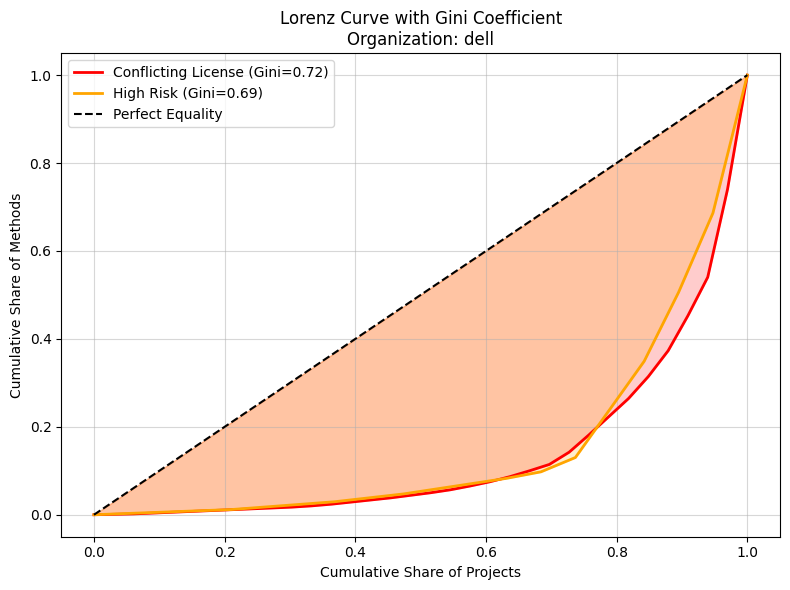

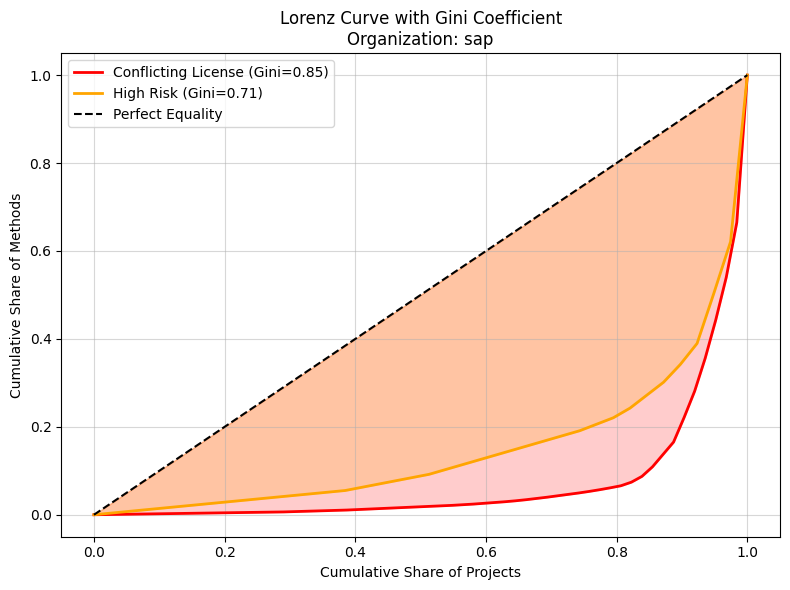

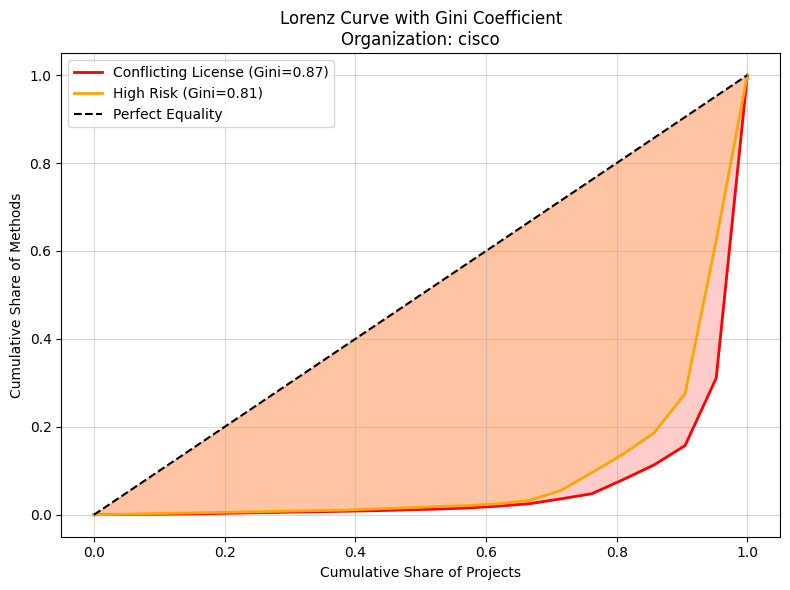

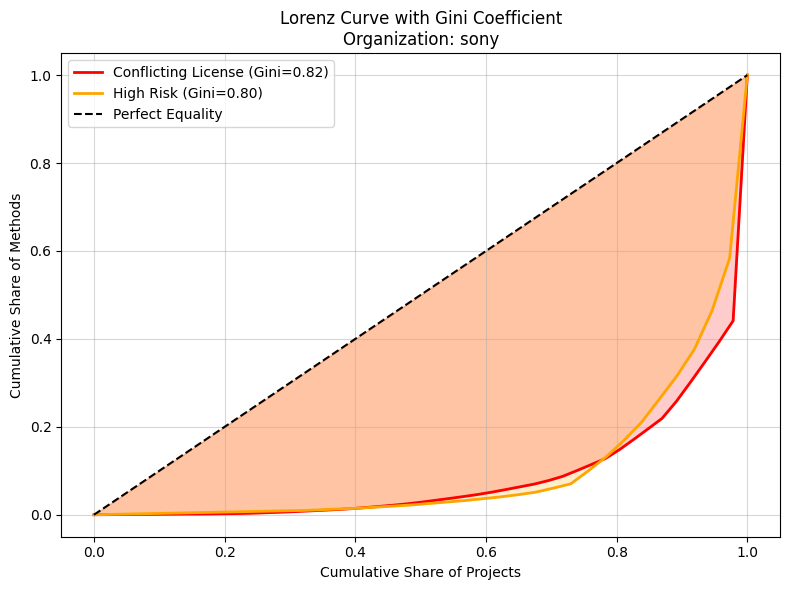

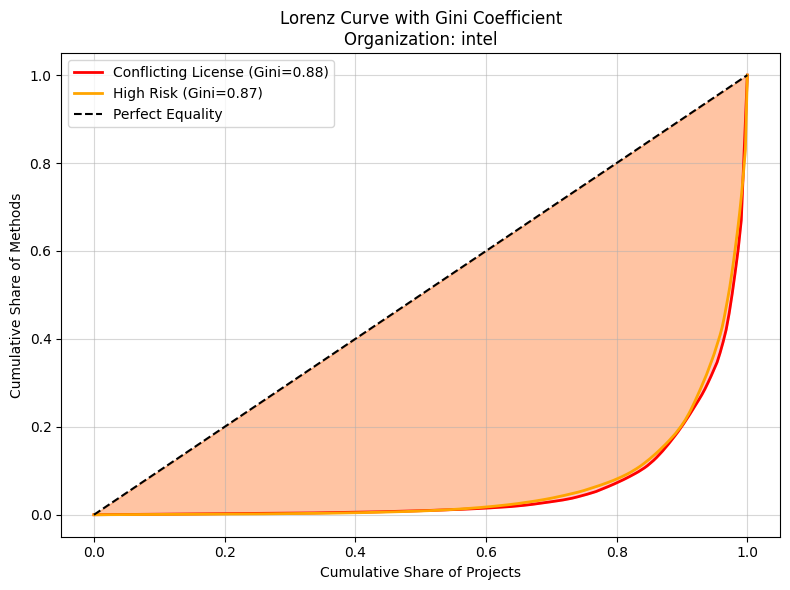

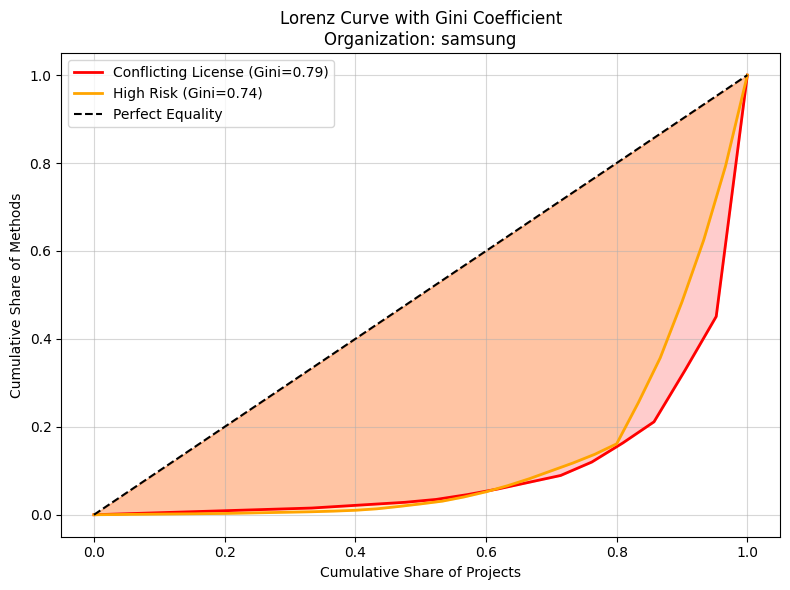

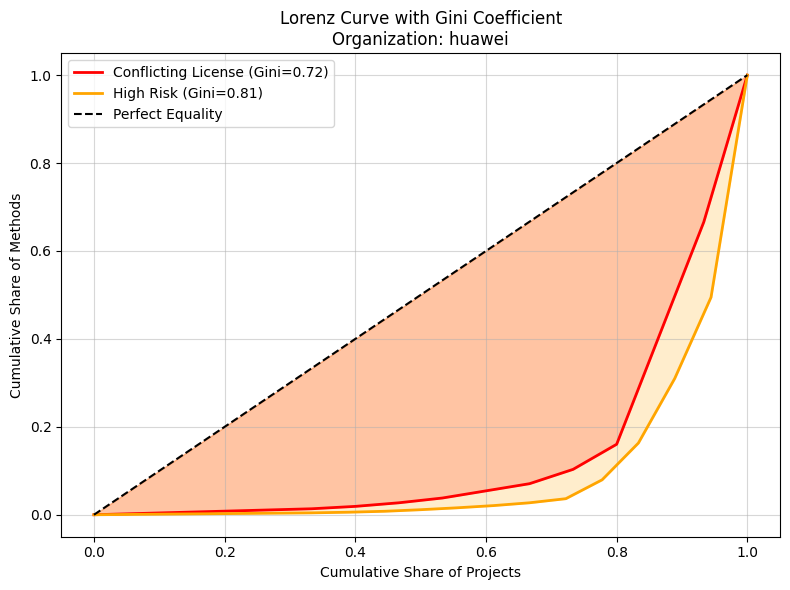

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from db_operations import get_db_conn

def fetch_conflict_highrisk_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            LOWER(organization),
            project_id,
            license_conflicts,
            high_risks
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = {}
    for row in cur.fetchall():
        org = row[0]
        proj = row[1]
        conflicts = row[2] or 0
        highrisk = row[3] or 0
        if org not in data:
            data[org] = {"conflict": [], "highrisk": []}
        if conflicts > 0:
            data[org]["conflict"].append((proj, conflicts))
        if highrisk > 0:
            data[org]["highrisk"].append((proj, highrisk))

    cur.close()
    conn.close()
    return data

def gini_coefficient(values):
    """Compute Gini coefficient for a numpy array of positive values"""
    values = np.sort(values)
    n = len(values)
    cumvals = np.cumsum(values)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

def plot_lorenz_with_gini_per_org(values, label, color):
    """Plot Lorenz curve for one org"""
    values = np.array([v for (_, v) in values])
    if len(values) == 0:
        return
    values = np.sort(values)
    n = len(values)

    cum_projects = np.arange(1, n+1) / n
    cum_values = np.cumsum(values) / values.sum()
    cum_projects = np.insert(cum_projects, 0, 0)
    cum_values = np.insert(cum_values, 0, 0)

    gini = gini_coefficient(values)
    plt.plot(cum_projects, cum_values, label=f"{label} (Gini={gini:.2f})", color=color, lw=2)
    plt.fill_between(cum_projects, cum_values, cum_projects, color=color, alpha=0.2)

if __name__ == "__main__":
    data = fetch_conflict_highrisk_data()

    for org, org_data in data.items():
        plt.figure(figsize=(8, 6))
        plot_lorenz_with_gini_per_org(org_data["conflict"], "Conflicting License", "red")
        plot_lorenz_with_gini_per_org(org_data["highrisk"], "High Risk", "orange")

        plt.plot([0, 1], [0, 1], 'k--', label="Perfect Equality")
        plt.xlabel("Cumulative Share of Projects")
        plt.ylabel("Cumulative Share of Methods")
        plt.title(f"Lorenz Curve with Gini Coefficient\nOrganization: {org}")
        plt.legend()
        plt.grid(alpha=0.5)
        plt.tight_layout()
        plt.show()


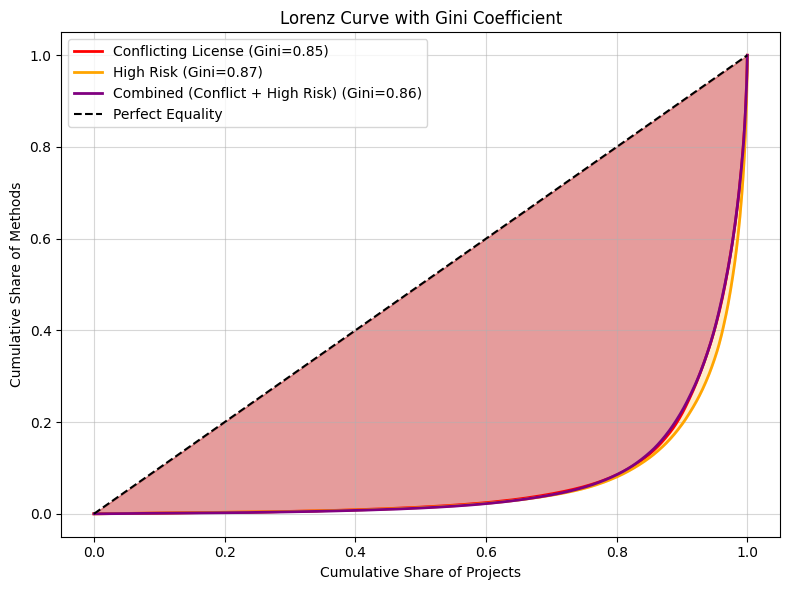

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from db_operations import get_db_conn

def fetch_conflict_highrisk_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            LOWER(organization),
            project_id,
            license_conflicts,
            high_risks
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = {"conflict": [], "highrisk": [], "combined": []}
    for row in cur.fetchall():
        org = row[0]
        proj = row[1]
        conflicts = row[2] or 0
        highrisk = row[3] or 0
        if conflicts > 0:
            data["conflict"].append((org, proj, conflicts))
        if highrisk > 0:
            data["highrisk"].append((org, proj, highrisk))
        if conflicts + highrisk > 0:
            data["combined"].append((org, proj, conflicts + highrisk))

    cur.close()
    conn.close()
    return data

def gini_coefficient(values):
    """Compute Gini coefficient for a numpy array of positive values"""
    values = np.sort(values)
    n = len(values)
    cumvals = np.cumsum(values)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

def plot_lorenz_with_gini(data, label, color):
    values = np.array([d[2] for d in data])
    if len(values) == 0:
        return
    values = np.sort(values)
    n = len(values)

    cum_projects = np.arange(1, n+1) / n
    cum_values = np.cumsum(values) / values.sum()
    cum_projects = np.insert(cum_projects, 0, 0)
    cum_values = np.insert(cum_values, 0, 0)

    gini = gini_coefficient(values)
    plt.plot(cum_projects, cum_values, label=f"{label} (Gini={gini:.2f})", color=color, lw=2)
    plt.fill_between(cum_projects, cum_values, cum_projects, color=color, alpha=0.2)

if __name__ == "__main__":
    data = fetch_conflict_highrisk_data()

    plt.figure(figsize=(8, 6))
    plot_lorenz_with_gini(data["conflict"], "Conflicting License", "red")
    plot_lorenz_with_gini(data["highrisk"], "High Risk", "orange")
    plot_lorenz_with_gini(data["combined"], "Combined (Conflict + High Risk)", "purple")

    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Equality")
    plt.xlabel("Cumulative Share of Projects")
    plt.ylabel("Cumulative Share of Methods")
    plt.title("Lorenz Curve with Gini Coefficient")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()


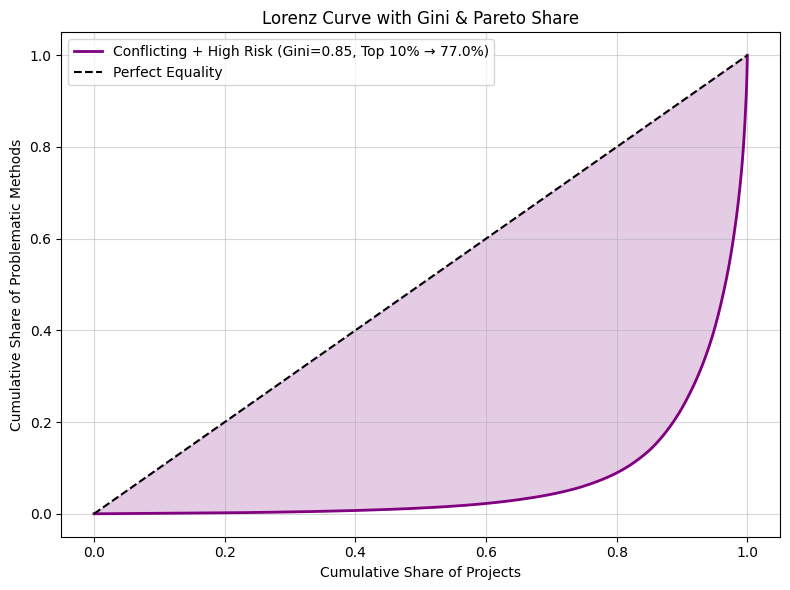

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from db_operations import get_db_conn

def fetch_conflict_highrisk_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            LOWER(organization),
            project_id,
            license_conflicts,
            high_risks
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    data = []
    for row in cur.fetchall():
        proj = row[1]
        conflicts = row[2] or 0
        highrisk = row[3] or 0
        total = conflicts + highrisk
        if total > 0:
            data.append((proj, total))

    cur.close()
    conn.close()
    return data

def gini_coefficient(values):
    """Compute Gini coefficient for a numpy array of positive values"""
    values = np.sort(values)
    n = len(values)
    cumvals = np.cumsum(values)
    return (n + 1 - 2 * np.sum(cumvals) / cumvals[-1]) / n

def pareto_share(values, top_fraction=0.1):
    """Compute what share of the total is contributed by the top X% of projects"""
    values = np.sort(values)[::-1]  # descending
    n = len(values)
    top_n = max(1, int(np.ceil(top_fraction * n)))
    top_sum = values[:top_n].sum()
    return top_sum / values.sum(), top_n

def plot_lorenz_with_gini(values, label, color):
    values = np.sort(values)
    n = len(values)

    cum_projects = np.arange(1, n+1) / n
    cum_values = np.cumsum(values) / values.sum()
    cum_projects = np.insert(cum_projects, 0, 0)
    cum_values = np.insert(cum_values, 0, 0)

    gini = gini_coefficient(values)
    share, top_n = pareto_share(values, top_fraction=0.1)

    plt.plot(cum_projects, cum_values,
             label=f"{label} (Gini={gini:.2f}, Top 10% → {share*100:.1f}%)",
             color=color, lw=2)
    plt.fill_between(cum_projects, cum_values, cum_projects, color=color, alpha=0.2)

if __name__ == "__main__":
    data = fetch_conflict_highrisk_data()
    values = np.array([d[1] for d in data])

    plt.figure(figsize=(8, 6))
    plot_lorenz_with_gini(values, "Conflicting + High Risk", "purple")

    plt.plot([0, 1], [0, 1], 'k--', label="Perfect Equality")
    plt.xlabel("Cumulative Share of Projects")
    plt.ylabel("Cumulative Share of Problematic Methods")
    plt.title("Lorenz Curve with Gini & Pareto Share")
    plt.legend()
    plt.grid(alpha=0.5)
    plt.tight_layout()
    plt.show()


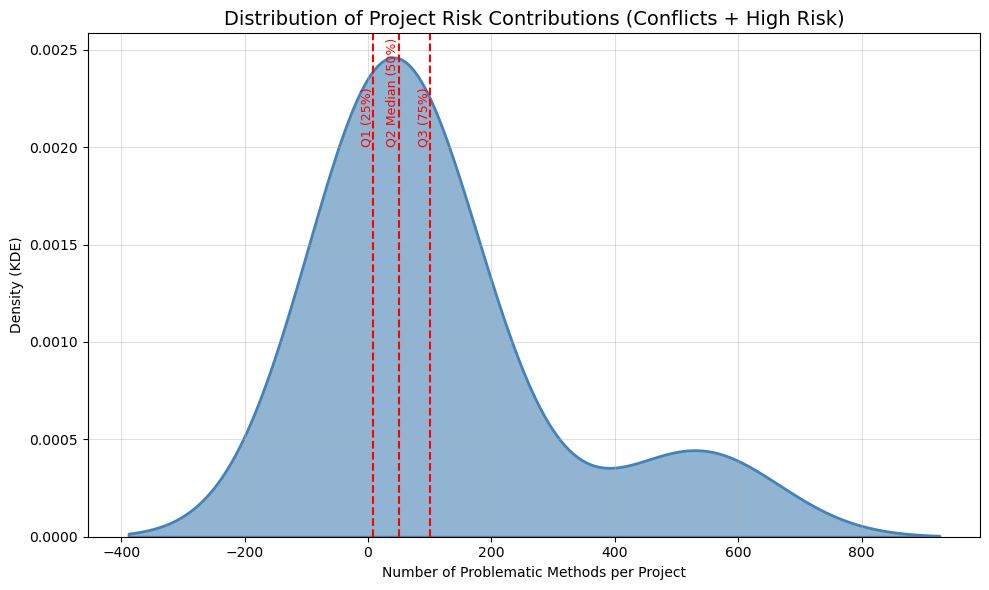

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from db_operations import get_db_conn

def fetch_combined_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            project_id,
            license_conflicts,
            high_risks
        FROM searchrepos
        WHERE is_active = FALSE AND project_type = 1
    """)

    combined = []
    for row in cur.fetchall():
        conflicts = row[1] or 0
        highrisk = row[2] or 0
        total = conflicts + highrisk
        if total > 0:
            combined.append(total)

    cur.close()
    conn.close()
    return np.array(combined)

if __name__ == "__main__":
    values = fetch_combined_data()

    # Compute quartiles
    q1, q2, q3 = np.percentile(values, [25, 50, 75])

    plt.figure(figsize=(10, 6))

    # Density plot (Gaussian-style smooth curve)
    sns.kdeplot(values, fill=True, color="steelblue", alpha=0.6, linewidth=2)

    # Add quartile markers
    for q, label in zip([q1, q2, q3], ["Q1 (25%)", "Q2 Median (50%)", "Q3 (75%)"]):
        plt.axvline(q, color="red", linestyle="--", linewidth=1.5)
        plt.text(q, 0.002, label, rotation=90, va="bottom", ha="right", fontsize=9, color="red")

    # Labels
    plt.title("Distribution of Project Risk Contributions (Conflicts + High Risk)", fontsize=14)
    plt.xlabel("Number of Problematic Methods per Project")
    plt.ylabel("Density (KDE)")
    plt.grid(alpha=0.4)
    plt.tight_layout()
    plt.show()


📊 Summary Statistics for Problematic Methods per Project
Projects analyzed: 168
Min: 1
Q1 (25%): 2.00
Median (Q2): 8.50
Q3 (75%): 43.00
Max: 1300
Mean: 51.05
Std Dev: 138.91
IQR (Q3 - Q1): 41.00


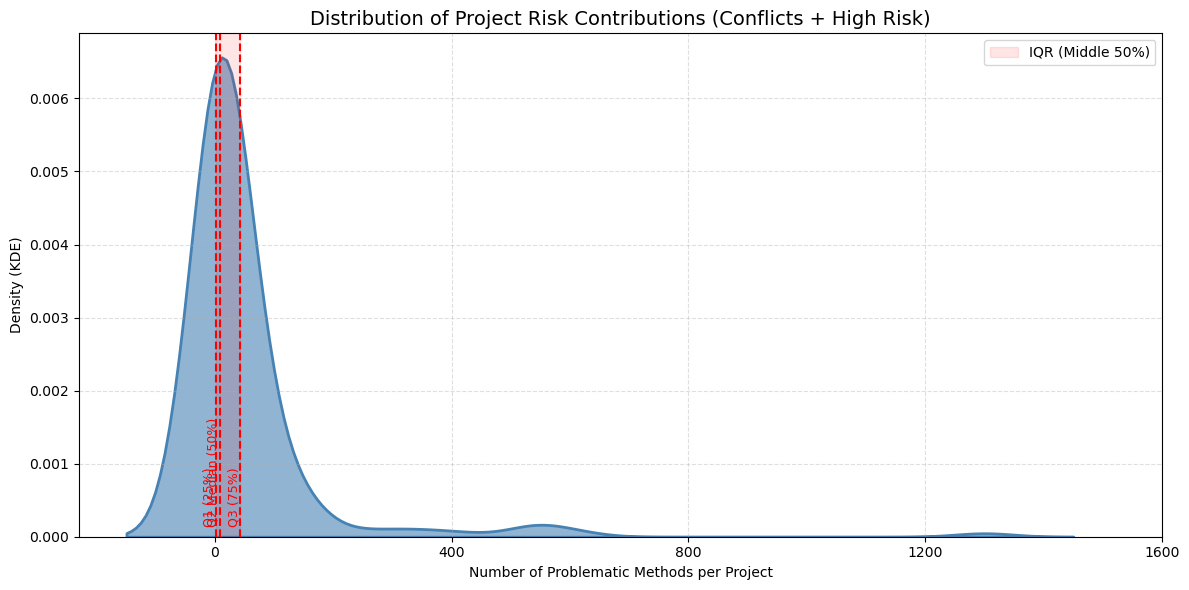

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from db_operations import get_db_conn

def fetch_combined_data():
    conn = get_db_conn()
    cur = conn.cursor()

    cur.execute("""
        SELECT
            project_id,
            license_conflicts,
            high_risks
        FROM searchrepos
        WHERE is_active = FALSE
    """)
    # is_active = FALSE AND project_type = 1 AND organization='Apple'
    combined = []
    for row in cur.fetchall():
        conflicts = row[1] or 0
        highrisk = row[2] or 0
        total = conflicts + highrisk
        if total > 0:
            combined.append(total)

    cur.close()
    conn.close()
    return np.array(combined)

def print_summary(values):
    q1, q2, q3 = np.percentile(values, [25, 50, 75])
    mean = np.mean(values)
    std = np.std(values)
    min_val, max_val = values.min(), values.max()

    print("\n📊 Summary Statistics for Problematic Methods per Project")
    print(f"Projects analyzed: {len(values)}")
    print(f"Min: {min_val}")
    print(f"Q1 (25%): {q1:.2f}")
    print(f"Median (Q2): {q2:.2f}")
    print(f"Q3 (75%): {q3:.2f}")
    print(f"Max: {max_val}")
    print(f"Mean: {mean:.2f}")
    print(f"Std Dev: {std:.2f}")
    print(f"IQR (Q3 - Q1): {q3 - q1:.2f}")

    return q1, q2, q3

if __name__ == "__main__":
    values = fetch_combined_data()
    q1, q2, q3 = print_summary(values)

    plt.figure(figsize=(12, 6))

    # KDE plot
    sns.kdeplot(values, fill=True, color="steelblue", alpha=0.6, linewidth=2)

    # Quartile markers
    for q, label in zip([q1, q2, q3], ["Q1 (25%)", "Q2 Median (50%)", "Q3 (75%)"]):
        plt.axvline(q, color="red", linestyle="--", linewidth=1.5)
        plt.text(q, plt.ylim()[1]*0.02, label, rotation=90, va="bottom", ha="right", fontsize=9, color="red")

    # Shade interquartile range (Q1–Q3)
    plt.axvspan(q1, q3, color="red", alpha=0.1, label="IQR (Middle 50%)")

    # X-axis ticks every 200
    plt.xticks(np.arange(0, values.max() + 400, 400))

    # Labels
    plt.title("Distribution of Project Risk Contributions (Conflicts + High Risk)", fontsize=14)
    plt.xlabel("Number of Problematic Methods per Project")
    plt.ylabel("Density (KDE)")
    plt.grid(alpha=0.4, linestyle="--", which="both", axis="both")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [30]:
from db_operations import get_db_conn

def count_unprocessed_records():
    conn = get_db_conn()
    cur = conn.cursor()

    query = """
        SELECT COUNT(repository_url)
        FROM searchrepos
        WHERE is_active=True AND has_picked=False;
    """
    
    cur.execute(query)
    count = cur.fetchone()[0]  # fetch single value

    print(f"Total unprocessed records: {count}")

    cur.close()
    conn.close()

# Run it
count_unprocessed_records()

Total unprocessed records: 33016


In [6]:
from db_operations import get_db_conn

def count_processed_records():
    conn = get_db_conn()
    cur = conn.cursor()

    query = """
        SELECT COUNT(repository_url)
        FROM searchrepos
        WHERE is_active=False AND has_picked=True;
    """
    
    cur.execute(query)
    count = cur.fetchone()[0]  # fetch single value

    print(f"Total processed records: {count}")

    cur.close()
    conn.close()

# Run it
count_processed_records()

Total processed records: 2


In [ ]:
#Periodically (e.g., daily or after ingesting N new repos) run
"""
from global_trivial_methods import build_and_store_global_trivial_names

build_and_store_global_trivial_names(file_path="../input_files/global_trivial_names.json")
"""

In [3]:
from global_trivial_methods import load_global_trivial_names
trivial_names = load_global_trivial_names(file_path="../input_files/global_trivial_names.json", threshold=30)

In [4]:
len(trivial_names)

1733

In [5]:
print(trivial_names)

{'Get', '_read', 'ba', 'dtype', 'accumulate', 'center', 'Dn', 'done', 'strndup', 'state_dict', 'reload', 'initialize', 'readObject', 'Stop', 'coerce', 'wi', 'unique', 'Ua', 'clip', 'ea', 'highlight', 'window_partition', 'Wn', 'train', 'text', 'body', 'decompress', 'event', 'distance', 'O', 'formatMessage', 'output', 'enqueue', 'capitalize', 'jt', 'activate', 'GetAsync', 'dn', 'br', '$r', 'Wi', '_normalize', 'path', 'de', 'classify', 'readlines', 'onComplete', 'OnDestroy', '_create_examples', 'fs', 'getContext', 'Connect', 'MoveNext', 'build', 'Ea', 'observe', 'Ia', 'setAttributes', 'input', 'has', 'add_item', 'sendMessage', 'ScrollSpy', 'record', '_write', 'of', 'fromValue', '[]', 'Main', 'download_file', 'asString', 'Mn', 'Parser', 'fetch', '__add__', 'error', 'sanitize', 'reorder', 'ri', 'Sa', 'getOffset', 'w', 'getFile', 'Xb', '_expand_mask', 'download', 'he', 'deleteFile', '_get_lr', 'tokenBase', 'report', 'cleanUp', 'scale', 'get_platform', 'get_special_tokens_mask', 'ne', 'drop_p